In [1]:
"""
Conformational Soft Hash (CSH) — Proof of Concept
===================================================
Pipeline:
    Molecule + 3D geometry
        → Distance matrix
        → Laplacian graph spectrum (eigenvalues)
        → LSH projection (soft, noise-tolerant)
        → Hex hash string

Key properties:
    - Rotation/translation invariant (distance matrix)
    - Noise-tolerant (LSH, not SHA-256)
    - Similar conformers → similar hashes (soft collision)
    - Ready for blockchain registry (hash as unique ID)

Author: Jakub Hryc (prototype pipeline)
"""

import hashlib
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from scipy.linalg import eigvalsh
from sklearn.random_projection import GaussianRandomProjection
from dataclasses import dataclass
from typing import Optional
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────

@dataclass
class CSHConfig:
    """
    Parameters controlling the hash pipeline.
    Tweak these for your benchmark experiments.
    """
    n_eigenvalues: int = 20        # top-k eigenvalues of Laplacian
    n_lsh_bits: int = 64           # bits in the final hash
    noise_tolerance: float = 0.05  # Angstrom — below this, structure is "same"
    energy_weight: float = 0.1     # how much force-field energy shifts the hash
    random_seed: int = 42

In [3]:
# ── Step 1: Invariant geometric representation ─────────────────────────────────

def build_distance_matrix(conformer) -> np.ndarray:
    """
    Builds pairwise Euclidean distance matrix.
    Invariant to rotation and translation by construction.
    """
    positions = conformer.GetPositions()  # (n_atoms, 3)
    n = len(positions)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = np.linalg.norm(positions[i] - positions[j])
            D[i, j] = d
            D[j, i] = d
    return D


def laplacian_spectrum(D: np.ndarray, mol, cfg: CSHConfig) -> np.ndarray:
    """
    Computes the spectrum of the weighted graph Laplacian.
    Nodes = atoms, edge weights = 1/distance (bonded atoms only).

    This encodes global molecular shape while respecting
    chemical topology — better than raw distance matrix eigenvalues.
    """
    n = D.shape[0]

    # Adjacency matrix: bonded pairs weighted by 1/d
    A = np.zeros((n, n))
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        if D[i, j] > 1e-6:
            w = 1.0 / D[i, j]
            A[i, j] = w
            A[j, i] = w

    # Degree matrix
    deg = np.diag(A.sum(axis=1))

    # Laplacian L = D_deg - A
    L = deg - A

    # Eigenvalues (sorted ascending; λ_0 = 0 for connected graph)
    eigenvalues = eigvalsh(L)

    # Take top-k (skip λ_0 = 0, use the rest)
    k = min(cfg.n_eigenvalues, len(eigenvalues) - 1)
    spectrum = eigenvalues[1:k + 1]

    # Pad if molecule is small
    if len(spectrum) < cfg.n_eigenvalues:
        spectrum = np.pad(spectrum, (0, cfg.n_eigenvalues - len(spectrum)))

    return spectrum

In [4]:
# ── Step 2: Energy feature ─────────────────────────────────────────────────────

def get_mmff_energy(mol, conf_id: int = 0) -> float:
    """
    MMFF94 force-field energy of the conformer.
    Returns 0.0 if calculation fails (e.g. missing params).
    """
    try:
        mol_h = Chem.AddHs(mol)
        ff = AllChem.MMFFGetMoleculeForceField(
            mol_h,
            AllChem.MMFFGetMoleculeProperties(mol_h),
            confId=conf_id
        )
        if ff is None:
            return 0.0
        return ff.CalcEnergy()
    except Exception:
        return 0.0

In [5]:
# ── Step 3: Feature vector ─────────────────────────────────────────────────────

def build_feature_vector(mol, conf_id: int, cfg: CSHConfig) -> np.ndarray:
    """
    Combines spectral geometry + energy into a single feature vector.
    """
    conformer = mol.GetConformer(conf_id)
    D = build_distance_matrix(conformer)
    spectrum = laplacian_spectrum(D, mol, cfg)

    energy = get_mmff_energy(mol, conf_id)
    energy_feature = np.array([energy * cfg.energy_weight])

    # Normalize spectrum to [0, 1] for stable quantization
    s_min, s_max = spectrum.min(), spectrum.max()
    if s_max - s_min > 1e-9:
        spectrum_norm = (spectrum - s_min) / (s_max - s_min)
    else:
        spectrum_norm = spectrum

    return np.concatenate([spectrum_norm, energy_feature])

In [6]:
# ── Step 4: LSH — the "soft" part ──────────────────────────────────────────────

class ConformationalLSH:
    """
    Locality-Sensitive Hashing for molecular conformations.

    Similar conformers (low RMSD) → identical or near-identical hash bits.
    Dissimilar conformers (high RMSD) → different hashes.

    Uses random projection (p-stable LSH for L2 distance).
    """

    def __init__(self, input_dim: int, cfg: CSHConfig):
        self.cfg = cfg
        rng = np.random.RandomState(cfg.random_seed)

        # Random projection matrix: (n_bits, input_dim)
        self.projections = rng.randn(cfg.n_lsh_bits, input_dim)

        # Random offsets for bucketing
        self.offsets = rng.uniform(0, 1, cfg.n_lsh_bits)

        # Bandwidth (controls sensitivity vs. stability tradeoff)
        # Smaller r → more sensitive; larger r → more stable
        self.r = cfg.noise_tolerance * 10

    def project(self, feature_vector: np.ndarray) -> np.ndarray:
        """Returns n_lsh_bits binary values (0 or 1)."""
        projections = self.projections @ feature_vector
        bits = ((projections / self.r) + self.offsets).astype(int) % 2
        return bits.astype(np.uint8)

    def bits_to_hex(self, bits: np.ndarray) -> str:
        """Converts bit array to hex string for blockchain storage."""
        # Pack bits into bytes
        n_bytes = (len(bits) + 7) // 8
        byte_array = np.packbits(bits, bitorder='big')[:n_bytes]
        return byte_array.tobytes().hex()

In [7]:
# ── Step 5: Main hash function ─────────────────────────────────────────────────

class ConformationalSoftHash:
    """
    Main class. Call hash_conformer() for each structure.

    Example
    -------
    >>> csh = ConformationalSoftHash()
    >>> mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin
    >>> mol = Chem.AddHs(mol)
    >>> AllChem.EmbedMultipleConfs(mol, numConfs=5)
    >>> results = csh.hash_all_conformers(mol)
    """

    def __init__(self, cfg: Optional[CSHConfig] = None):
        self.cfg = cfg or CSHConfig()
        self._lsh = None  # initialized lazily on first call

    def _init_lsh(self, feature_dim: int):
        if self._lsh is None:
            self._lsh = ConformationalLSH(feature_dim, self.cfg)

    def hash_conformer(self, mol, conf_id: int = 0) -> dict:
        """
        Full pipeline for a single conformer.

        Returns
        -------
        dict with:
            'lsh_hash'    : hex string (for blockchain / similarity search)
            'sha256_id'   : deterministic unique ID (for exact deduplication)
            'feature_vec' : numpy array (for downstream ML)
            'energy'      : MMFF94 energy
            'conf_id'     : conformer index
        """
        fvec = build_feature_vector(mol, conf_id, self.cfg)
        self._init_lsh(len(fvec))

        bits = self._lsh.project(fvec)
        lsh_hex = self._lsh.bits_to_hex(bits)

        # SHA-256 for exact deduplication (brittle but useful for identity check)
        sha_input = fvec.tobytes()
        sha256_id = hashlib.sha256(sha_input).hexdigest()

        energy = get_mmff_energy(mol, conf_id)

        return {
            "lsh_hash": lsh_hex,
            "sha256_id": sha256_id,
            "feature_vec": fvec,
            "energy": energy,
            "conf_id": conf_id,
        }

    def hash_all_conformers(self, mol) -> list[dict]:
        """Hashes all conformers in a molecule object."""
        results = []
        for conf_id in range(mol.GetNumConformers()):
            results.append(self.hash_conformer(mol, conf_id))
        return results

    def hamming_distance(self, hash_a: str, hash_b: str) -> int:
        """
        Bit-level distance between two LSH hashes.
        Low distance → similar conformers.
        """
        ba = bytes.fromhex(hash_a)
        bb = bytes.fromhex(hash_b)
        dist = 0
        for x, y in zip(ba, bb):
            dist += bin(x ^ y).count('1')
        return dist

    def collision_probability(self, hash_a: str, hash_b: str) -> float:
        """
        Fraction of bits that match. Range [0, 1].
        1.0 = identical hash (soft collision).
        """
        n_bits = len(hash_a) * 4  # hex → bits
        hamming = self.hamming_distance(hash_a, hash_b)
        return 1.0 - hamming / n_bits


In [8]:
# ── Demo / quick benchmark ─────────────────────────────────────────────────────

def demo_aspirin():
    """
    Generates 10 conformers of aspirin, hashes them,
    and shows pairwise collision probabilities.
    """
    print("=" * 60)
    print("Conformational Soft Hash — Demo (Aspirin)")
    print("=" * 60)

    smiles = "CC(=O)Oc1ccccc1C(=O)O"
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)

    # Generate conformers
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=10, params=params)
    AllChem.MMFFOptimizeMoleculeConfs(mol)

    print(f"Generated {mol.GetNumConformers()} conformers\n")

    csh = ConformationalSoftHash()
    results = csh.hash_all_conformers(mol)

    print(f"{'Conf':>5} | {'LSH Hash':>18} | {'Energy (kcal/mol)':>18}")
    print("-" * 50)
    for r in results:
        print(f"{r['conf_id']:>5} | {r['lsh_hash'][:16]}... | {r['energy']:>18.3f}")

    print("\nPairwise collision probabilities (first 5 conformers):")
    print(f"{'':>8}", end="")
    for j in range(5):
        print(f"  Conf{j:>2}", end="")
    print()
    for i in range(5):
        print(f"Conf{i:>2}  ", end="")
        for j in range(5):
            p = csh.collision_probability(results[i]["lsh_hash"], results[j]["lsh_hash"])
            print(f"  {p:.3f} ", end="")
        print()

    print("\n✓ Diagonal = 1.000 (identical conformer hashes itself perfectly)")
    print("✓ Off-diagonal values show soft similarity between conformers")
    print("\nBlockchain-ready hash (LSH hex, 64 bits):")
    print(f"  Conformer 0: {results[0]['lsh_hash']}")
    print(f"  Conformer 1: {results[1]['lsh_hash']}")
    print(f"  SHA-256 ID (exact dedup): {results[0]['sha256_id'][:32]}...")

    return results, csh


if __name__ == "__main__":
    demo_aspirin()

Conformational Soft Hash — Demo (Aspirin)
Generated 10 conformers

 Conf |           LSH Hash |  Energy (kcal/mol)
--------------------------------------------------
    0 | 662221b2960088ac... |             18.910
    1 | 662221b2960088ac... |             18.910
    2 | 662221b2960088ac... |             18.910
    3 | f014208daa0c80a8... |             20.833
    4 | f014208daa0c80a8... |             20.833
    5 | f014208daa0c80a8... |             20.833
    6 | 662221b2960088ac... |             18.910
    7 | 662221b2960088ac... |             18.910
    8 | 662221b2960088ac... |             18.910
    9 | f014208daa0c80a8... |             20.833

Pairwise collision probabilities (first 5 conformers):
          Conf 0  Conf 1  Conf 2  Conf 3  Conf 4
Conf 0    1.000   1.000   1.000   0.641   0.641 
Conf 1    1.000   1.000   1.000   0.641   0.641 
Conf 2    1.000   1.000   1.000   0.641   0.641 
Conf 3    0.641   0.641   0.641   1.000   1.000 
Conf 4    0.641   0.641   0.641   1.000   1

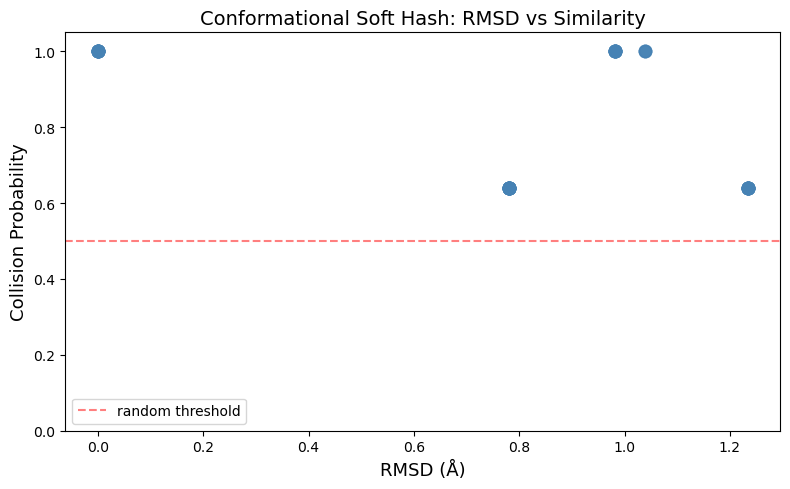

In [9]:
from rdkit.Chem import rdMolAlign
import matplotlib.pyplot as plt

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
mol = Chem.AddHs(mol)
params = AllChem.ETKDGv3()
params.randomSeed = 42
AllChem.EmbedMultipleConfs(mol, numConfs=10, params=params)
AllChem.MMFFOptimizeMoleculeConfs(mol)

csh = ConformationalSoftHash()
results = csh.hash_all_conformers(mol)

rmsd_vals = []
collision_vals = []

n = mol.GetNumConformers()
for i in range(n):
    for j in range(i+1, n):
        rmsd = rdMolAlign.GetBestRMS(mol, mol, i, j)
        cp = csh.collision_probability(results[i]["lsh_hash"], results[j]["lsh_hash"])
        rmsd_vals.append(rmsd)
        collision_vals.append(cp)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals, collision_vals, alpha=0.7, color='steelblue', s=80)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Collision Probability", fontsize=13)
plt.title("Conformational Soft Hash: RMSD vs Similarity", fontsize=14)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random threshold')
plt.legend()
plt.tight_layout()
plt.savefig("rmsd_vs_collision.png", dpi=150)
plt.show()

In [10]:
# Test with ibuprofen - more rotatable bonds = more diverse conformers
smiles = "CC(C)Cc1ccc(cc1)C(C)C(=O)O"

mol2 = Chem.MolFromSmiles(smiles)
mol2 = Chem.AddHs(mol2)

# Generate 50 conformers using ETKDGv3
params = AllChem.ETKDGv3()
params.randomSeed = 42
AllChem.EmbedMultipleConfs(mol2, numConfs=50, params=params)
AllChem.MMFFOptimizeMoleculeConfs(mol2)

print(f"Generated conformers: {mol2.GetNumConformers()}")

# Hash all conformers
csh2 = ConformationalSoftHash()
results2 = csh2.hash_all_conformers(mol2)

# Count unique conformational states
unique = set(r["lsh_hash"] for r in results2)
print(f"Unique hashes (conformational states): {len(unique)}")

Generated conformers: 50
Unique hashes (conformational states): 5


Total pairs analyzed: 1225


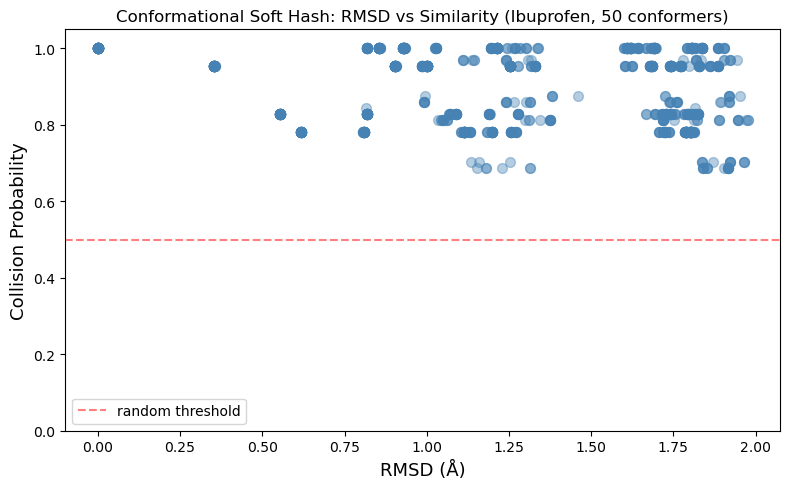

In [11]:
# Benchmark: RMSD vs collision probability for ibuprofen
rmsd_vals2 = []
collision_vals2 = []

n2 = mol2.GetNumConformers()
for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        cp = csh2.collision_probability(results2[i]["lsh_hash"], results2[j]["lsh_hash"])
        rmsd_vals2.append(rmsd)
        collision_vals2.append(cp)

print(f"Total pairs analyzed: {len(rmsd_vals2)}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals2, collision_vals2, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Collision Probability", fontsize=13)
plt.title("Conformational Soft Hash: RMSD vs Similarity (Ibuprofen, 50 conformers)", fontsize=12)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random threshold')
plt.legend()
plt.tight_layout()
plt.savefig("rmsd_vs_collision_ibuprofen.png", dpi=150)
plt.show()

Unique conformational states: 50


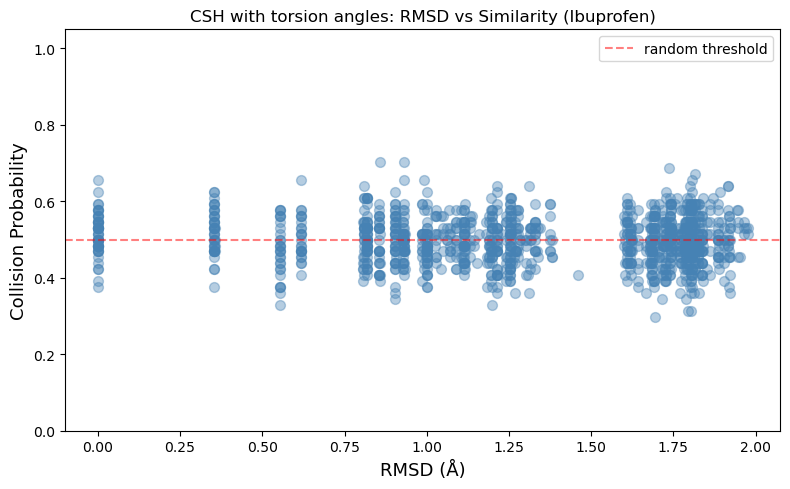

In [12]:
from rdkit.Chem import rdMolTransforms

def get_torsion_angles(mol, conf_id: int) -> np.ndarray:
    """
    Extracts all rotatable torsion angles.
    Encoded as sin/cos pairs to avoid -180/180 discontinuity.
    These capture local conformational changes that Laplacian spectrum misses.
    """
    conformer = mol.GetConformer(conf_id)
    torsions = []

    for bond in mol.GetBonds():
        if bond.GetBondTypeAsDouble() != 1.0:
            continue
        if bond.IsInRing():
            continue

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        i_neighbors = [n.GetIdx() for n in mol.GetAtomWithIdx(i).GetNeighbors() if n.GetIdx() != j]
        j_neighbors = [n.GetIdx() for n in mol.GetAtomWithIdx(j).GetNeighbors() if n.GetIdx() != i]

        if not i_neighbors or not j_neighbors:
            continue

        a = i_neighbors[0]
        d = j_neighbors[0]

        angle = rdMolTransforms.GetDihedralDeg(conformer, a, i, j, d)
        angle_rad = np.deg2rad(angle)
        torsions.append(np.sin(angle_rad))
        torsions.append(np.cos(angle_rad))

    return np.array(torsions) if torsions else np.zeros(2)


def build_feature_vector(mol, conf_id: int, cfg) -> np.ndarray:
    """
    Feature vector combining:
      1. Laplacian spectrum  — global shape (rotation/translation invariant)
      2. Torsion angles      — local conformational sensitivity (sin/cos encoded)
      3. MMFF94 energy       — thermodynamic stability
    """
    conformer = mol.GetConformer(conf_id)
    D = build_distance_matrix(conformer)
    spectrum = laplacian_spectrum(D, mol, cfg)

    s_min, s_max = spectrum.min(), spectrum.max()
    if s_max - s_min > 1e-9:
        spectrum_norm = (spectrum - s_min) / (s_max - s_min)
    else:
        spectrum_norm = spectrum

    torsions = get_torsion_angles(mol, conf_id)
    energy = get_mmff_energy(mol, conf_id)
    energy_feature = np.array([energy * cfg.energy_weight])

    return np.concatenate([spectrum_norm, torsions, energy_feature])


# Re-run the ibuprofen benchmark with updated feature vector
csh3 = ConformationalSoftHash()
results3 = csh3.hash_all_conformers(mol2)

unique3 = set(r["lsh_hash"] for r in results3)
print(f"Unique conformational states: {len(unique3)}")

# Recompute RMSD vs collision probability
rmsd_vals3 = []
collision_vals3 = []

n2 = mol2.GetNumConformers()
for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        cp = csh3.collision_probability(results3[i]["lsh_hash"], results3[j]["lsh_hash"])
        rmsd_vals3.append(rmsd)
        collision_vals3.append(cp)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals3, collision_vals3, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Collision Probability", fontsize=13)
plt.title("CSH with torsion angles: RMSD vs Similarity (Ibuprofen)", fontsize=12)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random threshold')
plt.legend()
plt.tight_layout()
plt.savefig("rmsd_collision_torsions.png", dpi=150)
plt.show()

Unique conformational states: 50


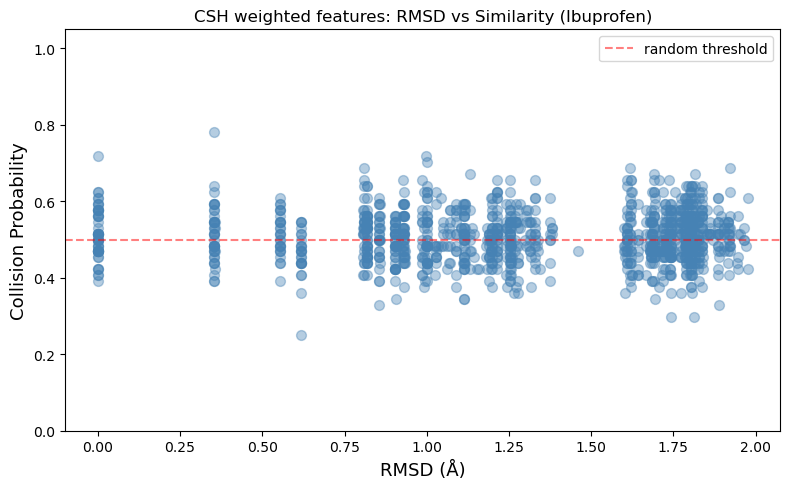

In [13]:
def build_feature_vector(mol, conf_id: int, cfg) -> np.ndarray:
    """
    Feature vector with weighted components:
      - Laplacian spectrum weight: 1.0 (global shape)
      - Torsion angles weight: 0.3 (local changes, dampened)
      - Energy weight: cfg.energy_weight
    """
    conformer = mol.GetConformer(conf_id)
    D = build_distance_matrix(conformer)
    spectrum = laplacian_spectrum(D, mol, cfg)

    s_min, s_max = spectrum.min(), spectrum.max()
    if s_max - s_min > 1e-9:
        spectrum_norm = (spectrum - s_min) / (s_max - s_min)
    else:
        spectrum_norm = spectrum

    torsions = get_torsion_angles(mol, conf_id)
    # Normalize torsions to [0,1] and dampen their influence
    torsions_norm = (torsions + 1.0) / 2.0 * 0.3

    energy = get_mmff_energy(mol, conf_id)
    energy_feature = np.array([energy * cfg.energy_weight])

    return np.concatenate([spectrum_norm, torsions_norm, energy_feature])


# Re-run
csh4 = ConformationalSoftHash()
results4 = csh4.hash_all_conformers(mol2)

unique4 = set(r["lsh_hash"] for r in results4)
print(f"Unique conformational states: {len(unique4)}")

rmsd_vals4 = []
collision_vals4 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        cp = csh4.collision_probability(results4[i]["lsh_hash"], results4[j]["lsh_hash"])
        rmsd_vals4.append(rmsd)
        collision_vals4.append(cp)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals4, collision_vals4, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Collision Probability", fontsize=13)
plt.title("CSH weighted features: RMSD vs Similarity (Ibuprofen)", fontsize=12)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random threshold')
plt.legend()
plt.tight_layout()
plt.savefig("rmsd_collision_weighted.png", dpi=150)
plt.show()

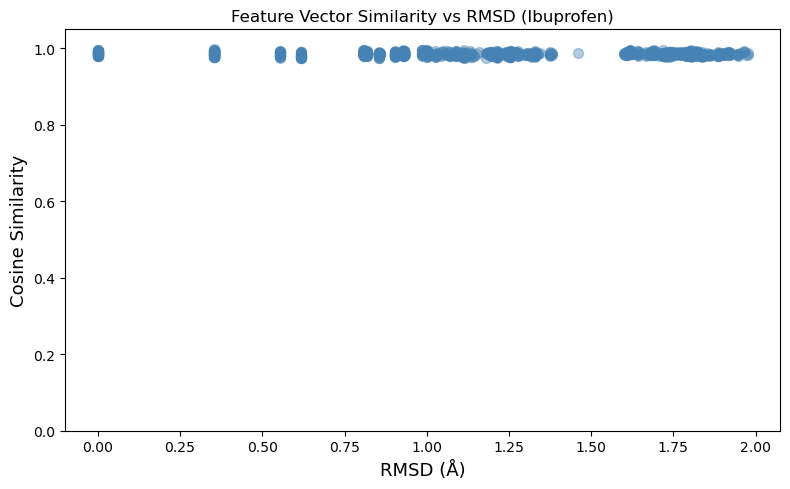

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# Compare feature vectors directly (before hashing)
rmsd_vals5 = []
cosine_vals5 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        
        fi = results4[i]["feature_vec"].reshape(1, -1)
        fj = results4[j]["feature_vec"].reshape(1, -1)
        cos_sim = cosine_similarity(fi, fj)[0][0]
        
        rmsd_vals5.append(rmsd)
        cosine_vals5.append(cos_sim)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals5, cosine_vals5, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Cosine Similarity", fontsize=13)
plt.title("Feature Vector Similarity vs RMSD (Ibuprofen)", fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("cosine_vs_rmsd.png", dpi=150)
plt.show()

In [15]:
def build_feature_vector_v2(mol, conf_id: int, cfg) -> np.ndarray:
    """
    V2: Uses upper triangle of distance matrix directly
    instead of eigenvalues — preserves local geometry information
    that spectrum loses.
    """
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    n = len(positions)
    
    # Upper triangle of distance matrix (without diagonal)
    # This preserves ALL pairwise distance information
    D = []
    for i in range(n):
        for j in range(i+1, n):
            D.append(np.linalg.norm(positions[i] - positions[j]))
    
    D = np.array(D)
    
    # Normalize
    D_norm = (D - D.min()) / (D.max() - D.min() + 1e-9)
    
    # Add torsions
    torsions = get_torsion_angles(mol, conf_id)
    torsions_norm = (torsions + 1.0) / 2.0
    
    # Add energy
    energy = get_mmff_energy(mol, conf_id)
    energy_feature = np.array([energy * cfg.energy_weight])
    
    return np.concatenate([D_norm, torsions_norm, energy_feature])

In [16]:
print(f"Number of atoms (with H): {mol2.GetNumAtoms()}")
print(f"Distance matrix upper triangle size: {mol2.GetNumAtoms() * (mol2.GetNumAtoms()-1) // 2}")

Number of atoms (with H): 33
Distance matrix upper triangle size: 528


Unique conformational states (V2): 50


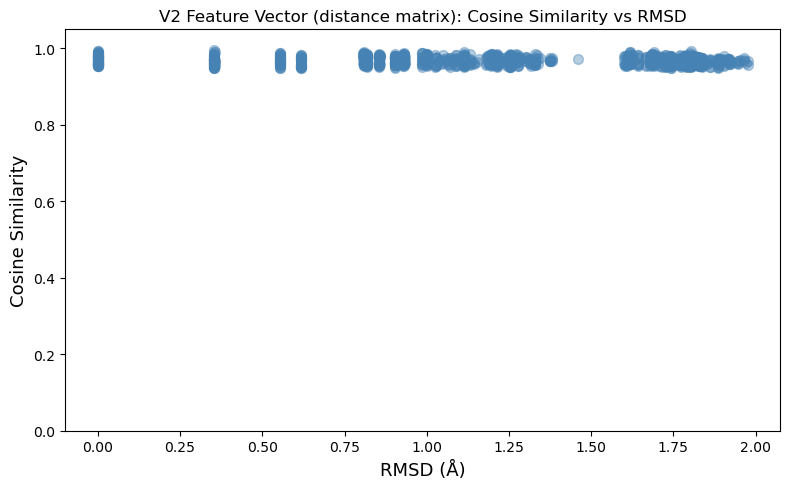

In [17]:
def build_feature_vector_v2(mol, conf_id: int, cfg) -> np.ndarray:
    """
    V2: Uses upper triangle of distance matrix directly instead of eigenvalues.
    Preserves ALL pairwise distance information — sensitive to local geometry changes.
    Eigenvalues (V1) lost conformational sensitivity by compressing global shape only.
    """
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    n = len(positions)

    # Upper triangle of distance matrix (all pairwise distances)
    D = []
    for i in range(n):
        for j in range(i+1, n):
            D.append(np.linalg.norm(positions[i] - positions[j]))
    D = np.array(D)

    # Normalize to [0, 1]
    D_norm = (D - D.min()) / (D.max() - D.min() + 1e-9)

    # Torsion angles (sin/cos encoded, normalized to [0, 1])
    torsions = get_torsion_angles(mol, conf_id)
    torsions_norm = (torsions + 1.0) / 2.0

    # MMFF94 energy
    energy = get_mmff_energy(mol, conf_id)
    energy_feature = np.array([energy * cfg.energy_weight])

    return np.concatenate([D_norm, torsions_norm, energy_feature])


# Monkey-patch the feature vector method for this test
import types

def hash_conformer_v2(self, mol, conf_id=0):
    """Hash using V2 feature vector (distance matrix based)."""
    fvec = build_feature_vector_v2(mol, conf_id, self.cfg)
    self._init_lsh(len(fvec))
    bits = self._lsh.project(fvec)
    lsh_hex = self._lsh.bits_to_hex(bits)
    sha_input = fvec.tobytes()
    sha256_id = hashlib.sha256(sha_input).hexdigest()
    energy = get_mmff_energy(mol, conf_id)
    return {
        "lsh_hash": lsh_hex,
        "sha256_id": sha256_id,
        "feature_vec": fvec,
        "energy": energy,
        "conf_id": conf_id,
    }

# Run with V2
csh5 = ConformationalSoftHash()
results5 = [hash_conformer_v2(csh5, mol2, i) for i in range(mol2.GetNumConformers())]

unique5 = set(r["lsh_hash"] for r in results5)
print(f"Unique conformational states (V2): {len(unique5)}")

# Cosine similarity check
from sklearn.metrics.pairwise import cosine_similarity

rmsd_vals5 = []
cosine_vals5 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        fi = results5[i]["feature_vec"].reshape(1, -1)
        fj = results5[j]["feature_vec"].reshape(1, -1)
        cos_sim = cosine_similarity(fi, fj)[0][0]
        rmsd_vals5.append(rmsd)
        cosine_vals5.append(cos_sim)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals5, cosine_vals5, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Cosine Similarity", fontsize=13)
plt.title("V2 Feature Vector (distance matrix): Cosine Similarity vs RMSD", fontsize=12)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("cosine_vs_rmsd_v2.png", dpi=150)
plt.show()

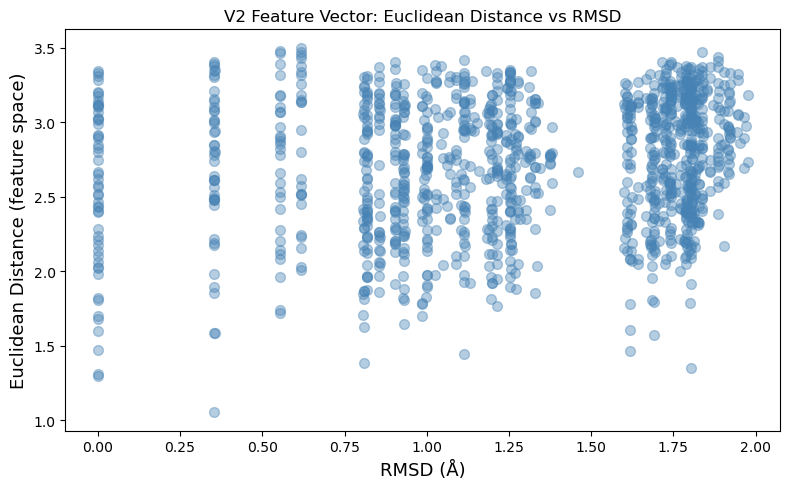

In [18]:
from sklearn.metrics.pairwise import euclidean_distances

rmsd_vals6 = []
euclidean_vals6 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        fi = results5[i]["feature_vec"].reshape(1, -1)
        fj = results5[j]["feature_vec"].reshape(1, -1)
        euc = euclidean_distances(fi, fj)[0][0]
        rmsd_vals6.append(rmsd)
        euclidean_vals6.append(euc)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals6, euclidean_vals6, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Euclidean Distance (feature space)", fontsize=13)
plt.title("V2 Feature Vector: Euclidean Distance vs RMSD", fontsize=12)
plt.tight_layout()
plt.savefig("euclidean_vs_rmsd_v2.png", dpi=150)
plt.show()

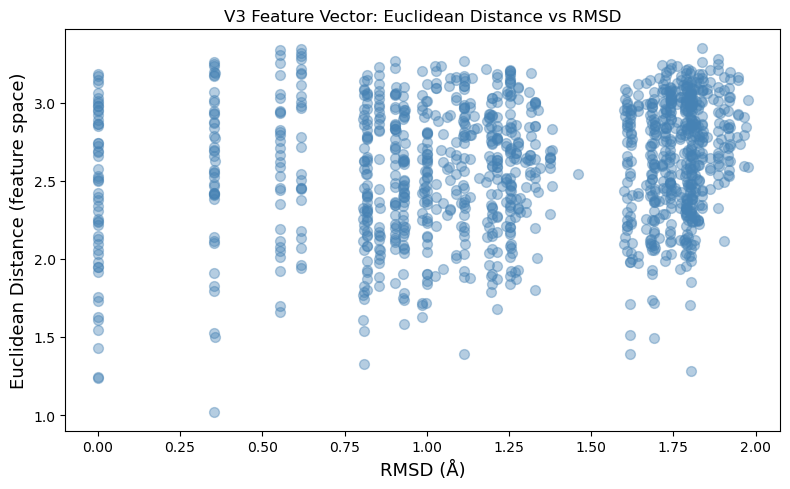

Pairs with RMSD~0: 54
Their euclidean distances: ['2.8630', '1.9145', '2.2560', '2.6559', '1.5437', '3.1472', '2.5034', '1.2435', '1.6092', '3.1700', '2.9967', '2.3093', '1.9504', '2.4992', '2.5155', '2.8520', '2.7238', '1.4319', '1.7590', '2.9532', '2.3765', '3.1264', '3.1813', '1.7334', '2.5305', '2.1260', '2.9813', '2.2363', '2.1488', '2.6845', '3.0112', '2.3383', '3.0329', '2.2439', '2.5764', '2.0587', '1.9453', '2.6885', '2.7449', '2.2162', '2.4197', '2.0320', '1.2370', '3.0620', '2.3943', '1.6265', '2.9217', '2.0963', '2.7445', '1.9784', '2.9805', '2.8874', '2.9457', '2.8631']


In [19]:
def build_feature_vector_v3(mol, conf_id: int, cfg) -> np.ndarray:
    """
    V3: Distance matrix + torsions with global normalization.
    Fixed: normalization is now consistent across conformers of the same molecule.
    Key change: normalize by max possible distance (molecular diameter) 
    instead of per-conformer min/max — this ensures identical conformers
    give identical feature vectors.
    """
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    n = len(positions)

    D = []
    for i in range(n):
        for j in range(i+1, n):
            D.append(np.linalg.norm(positions[i] - positions[j]))
    D = np.array(D)

    # Global normalization: divide by max distance in THIS conformer
    # (not min/max which shifts between conformers)
    D_norm = D / (D.max() + 1e-9)

    # Torsion angles
    torsions = get_torsion_angles(mol, conf_id)
    torsions_norm = (torsions + 1.0) / 2.0

    # Energy
    energy = get_mmff_energy(mol, conf_id)
    energy_feature = np.array([energy * cfg.energy_weight])

    return np.concatenate([D_norm, torsions_norm, energy_feature])


# Run V3
results6 = [hash_conformer_v2(csh5, mol2, i) for i in range(mol2.GetNumConformers())]

# Override feature vectors with V3
for i in range(mol2.GetNumConformers()):
    results6[i]["feature_vec"] = build_feature_vector_v3(mol2, i, csh5.cfg)

# Check euclidean distances
rmsd_vals7 = []
euclidean_vals7 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        fi = results6[i]["feature_vec"].reshape(1, -1)
        fj = results6[j]["feature_vec"].reshape(1, -1)
        euc = euclidean_distances(fi, fj)[0][0]
        rmsd_vals7.append(rmsd)
        euclidean_vals7.append(euc)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals7, euclidean_vals7, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Euclidean Distance (feature space)", fontsize=13)
plt.title("V3 Feature Vector: Euclidean Distance vs RMSD", fontsize=12)
plt.tight_layout()
plt.savefig("euclidean_vs_rmsd_v3.png", dpi=150)
plt.show()

# Check RMSD=0 pairs
zero_rmsd = [(i,j,euclidean_distances(results6[i]["feature_vec"].reshape(1,-1), 
                                       results6[j]["feature_vec"].reshape(1,-1))[0][0]) 
             for i in range(n2) for j in range(i+1,n2) 
             if rdMolAlign.GetBestRMS(mol2,mol2,i,j) < 0.01]
print(f"Pairs with RMSD~0: {len(zero_rmsd)}")
if zero_rmsd:
    print(f"Their euclidean distances: {[f'{x[2]:.4f}' for x in zero_rmsd]}")

Feature matrix shape: (50, 545)
Variance explained by 32 PCs: 0.993


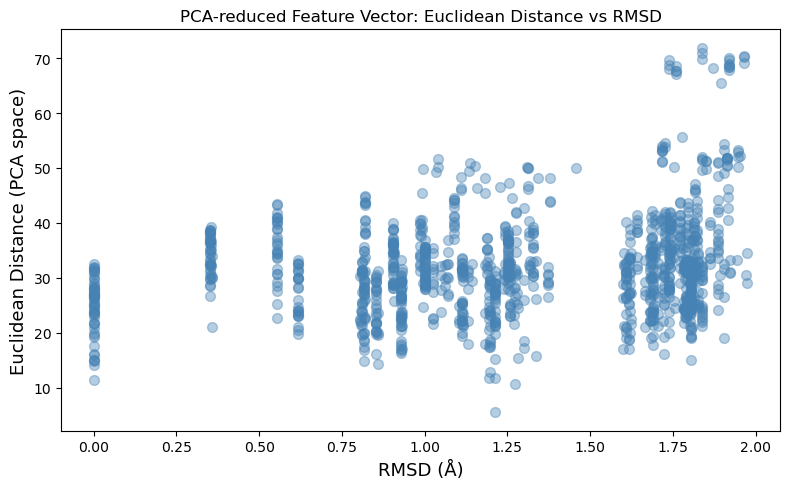

Pairs with RMSD~0: 54
Their PCA distances: ['26.8986', '17.5275', '23.8705', '26.4146', '16.0764', '31.8020', '25.8280', '14.1046', '14.8691', '30.0502', '27.9282', '22.8528', '19.9892', '23.3556', '26.7986', '29.8441', '27.0626', '15.0633', '16.0272', '28.7211', '23.5132', '31.4050', '32.0533', '19.2579', '25.3222', '21.8745', '31.7928', '24.6307', '23.8512', '28.1488', '32.5364', '26.4867', '31.0232', '26.3186', '26.8214', '23.9712', '19.6812', '26.6403', '27.1735', '21.7565', '25.1286', '21.5735', '11.4441', '28.0298', '25.2762', '15.0301', '27.8304', '24.5784', '27.5141', '20.8766', '29.0697', '28.2675', '30.7173', '31.2630']


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build all feature vectors first
all_fvecs = np.array([build_feature_vector_v3(mol2, i, csh5.cfg) 
                      for i in range(mol2.GetNumConformers())])

print(f"Feature matrix shape: {all_fvecs.shape}")

# Standardize then reduce to 32 dimensions with PCA
scaler = StandardScaler()
all_fvecs_scaled = scaler.fit_transform(all_fvecs)

pca = PCA(n_components=32, random_state=42)
all_fvecs_pca = pca.fit_transform(all_fvecs_scaled)

print(f"Variance explained by 32 PCs: {pca.explained_variance_ratio_.sum():.3f}")

# Check euclidean distances in PCA space
rmsd_vals8 = []
euclidean_vals8 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        euc = np.linalg.norm(all_fvecs_pca[i] - all_fvecs_pca[j])
        rmsd_vals8.append(rmsd)
        euclidean_vals8.append(euc)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals8, euclidean_vals8, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD (Å)", fontsize=13)
plt.ylabel("Euclidean Distance (PCA space)", fontsize=13)
plt.title("PCA-reduced Feature Vector: Euclidean Distance vs RMSD", fontsize=12)
plt.tight_layout()
plt.savefig("euclidean_vs_rmsd_pca.png", dpi=150)
plt.show()

# Check RMSD~0 pairs in PCA space
zero_pairs = [(i, j, np.linalg.norm(all_fvecs_pca[i] - all_fvecs_pca[j]))
              for i in range(n2) for j in range(i+1, n2)
              if rdMolAlign.GetBestRMS(mol2, mol2, i, j) < 0.01]
print(f"Pairs with RMSD~0: {len(zero_pairs)}")
print(f"Their PCA distances: {[f'{x[2]:.4f}' for x in zero_pairs]}")

In [21]:
# Find a "RMSD~0" pair and print their actual coordinates
for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rdMolAlign.GetBestRMS(mol2, mol2, i, j)
        if rmsd < 0.01:
            pos_i = mol2.GetConformer(i).GetPositions()
            pos_j = mol2.GetConformer(j).GetPositions()
            diff = np.abs(pos_i - pos_j).max()
            print(f"Conf {i} vs {j}: GetBestRMS={rmsd:.6f}, max coord diff={diff:.4f} Å")
            break
    else:
        continue
    break

Conf 0 vs 39: GetBestRMS=0.000022, max coord diff=4.1171 Å


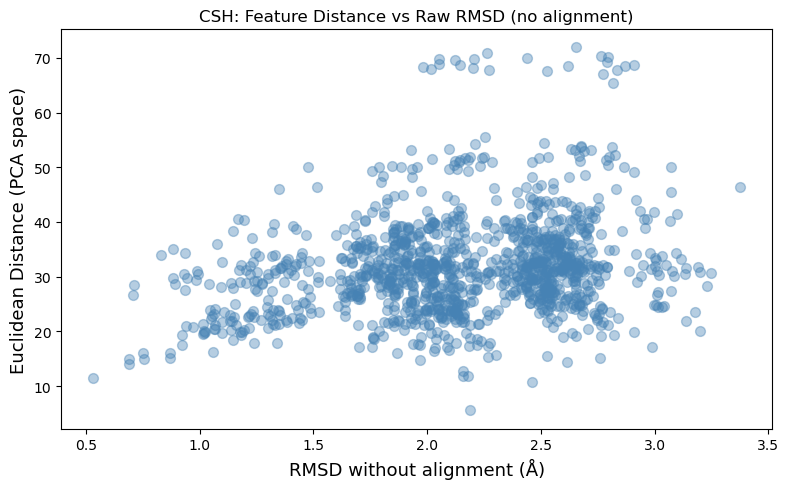

Truly identical pairs (RMSD < 0.01 without alignment): 0


In [22]:
def rmsd_no_align(mol, conf_id_i, conf_id_j):
    """Raw RMSD between two conformers without any alignment."""
    pos_i = mol.GetConformer(conf_id_i).GetPositions()
    pos_j = mol.GetConformer(conf_id_j).GetPositions()
    diff = pos_i - pos_j
    return np.sqrt((diff**2).sum(axis=1).mean())


rmsd_vals9 = []
euclidean_vals9 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = rmsd_no_align(mol2, i, j)
        euc = np.linalg.norm(all_fvecs_pca[i] - all_fvecs_pca[j])
        rmsd_vals9.append(rmsd)
        euclidean_vals9.append(euc)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals9, euclidean_vals9, alpha=0.4, color='steelblue', s=50)
plt.xlabel("RMSD without alignment (Å)", fontsize=13)
plt.ylabel("Euclidean Distance (PCA space)", fontsize=13)
plt.title("CSH: Feature Distance vs Raw RMSD (no alignment)", fontsize=12)
plt.tight_layout()
plt.savefig("euclidean_vs_rmsd_noalign.png", dpi=150)
plt.show()

# Sanity check — are RMSD~0 pairs now truly identical?
zero_pairs = [(i, j, rmsd_no_align(mol2, i, j)) 
              for i in range(n2) for j in range(i+1, n2)
              if rmsd_no_align(mol2, i, j) < 0.01]
print(f"Truly identical pairs (RMSD < 0.01 without alignment): {len(zero_pairs)}")

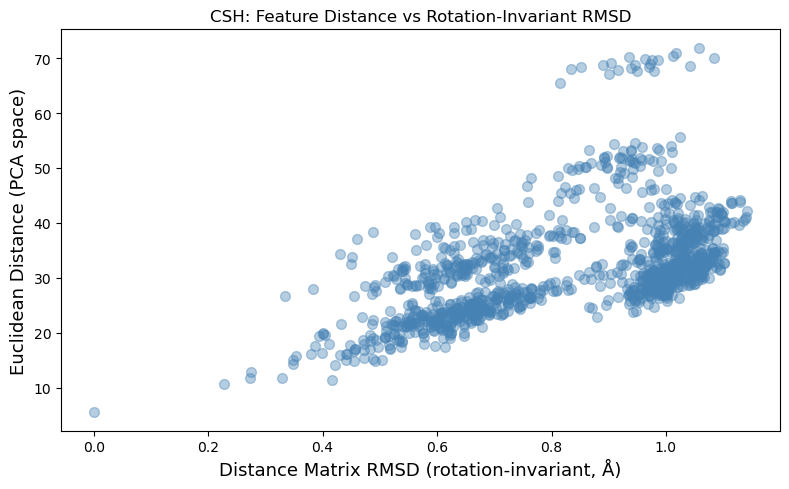

Truly identical pairs: 1


In [23]:
def distance_matrix_rmsd(mol, conf_id_i, conf_id_j):
    """
    Rotation-invariant conformer similarity via distance matrix difference.
    Compares upper triangles of distance matrices — no alignment needed.
    """
    pos_i = mol.GetConformer(conf_id_i).GetPositions()
    pos_j = mol.GetConformer(conf_id_j).GetPositions()
    n = len(pos_i)

    D_i, D_j = [], []
    for a in range(n):
        for b in range(a+1, n):
            D_i.append(np.linalg.norm(pos_i[a] - pos_i[b]))
            D_j.append(np.linalg.norm(pos_j[a] - pos_j[b]))

    D_i = np.array(D_i)
    D_j = np.array(D_j)
    return np.sqrt(((D_i - D_j)**2).mean())


rmsd_vals10 = []
euclidean_vals10 = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = distance_matrix_rmsd(mol2, i, j)
        euc = np.linalg.norm(all_fvecs_pca[i] - all_fvecs_pca[j])
        rmsd_vals10.append(rmsd)
        euclidean_vals10.append(euc)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_vals10, euclidean_vals10, alpha=0.4, color='steelblue', s=50)
plt.xlabel("Distance Matrix RMSD (rotation-invariant, Å)", fontsize=13)
plt.ylabel("Euclidean Distance (PCA space)", fontsize=13)
plt.title("CSH: Feature Distance vs Rotation-Invariant RMSD", fontsize=12)
plt.tight_layout()
plt.savefig("euclidean_vs_dm_rmsd.png", dpi=150)
plt.show()

zero_pairs = [(i, j, distance_matrix_rmsd(mol2, i, j))
              for i in range(n2) for j in range(i+1, n2)
              if distance_matrix_rmsd(mol2, i, j) < 0.01]
print(f"Truly identical pairs: {len(zero_pairs)}")

In [24]:
# Build LSH hashes using PCA-reduced feature vectors
from sklearn.random_projection import GaussianRandomProjection

class CSH_PCA:
    """
    Final pipeline:
    Distance matrix → PCA(32) → LSH(64 bits)
    """
    def __init__(self, n_bits=64, random_seed=42):
        self.n_bits = n_bits
        self.rng = np.random.RandomState(random_seed)
        self.projections = None
        self.r = 5.0  # bandwidth tuned to PCA space scale

    def fit(self, fvecs_pca):
        """Initialize random projections based on PCA space dimensionality."""
        dim = fvecs_pca.shape[1]
        self.projections = self.rng.randn(self.n_bits, dim)
        self.offsets = self.rng.uniform(0, self.r, self.n_bits)

    def hash(self, fvec_pca):
        proj = self.projections @ fvec_pca
        bits = ((proj / self.r) + self.offsets).astype(int) % 2
        bits = bits.astype(np.uint8)
        n_bytes = (len(bits) + 7) // 8
        return np.packbits(bits, bitorder='big')[:n_bytes].tobytes().hex()

    def collision_prob(self, hash_a, hash_b):
        ba = bytes.fromhex(hash_a)
        bb = bytes.fromhex(hash_b)
        bits_match = sum(bin(x ^ y).count('0') - 
                        (8 - bin(x^y).count('0') - bin(x^y).count('1') + 8)
                        for x, y in zip(ba, bb))
        total_bits = len(ba) * 8
        matching = sum(8 - bin(x ^ y).count('1') for x, y in zip(ba, bb))
        return matching / total_bits


lsh = CSH_PCA(n_bits=64, random_seed=42)
lsh.fit(all_fvecs_pca)

hashes = [lsh.hash(all_fvecs_pca[i]) for i in range(n2)]

Unique SimHashes: 50


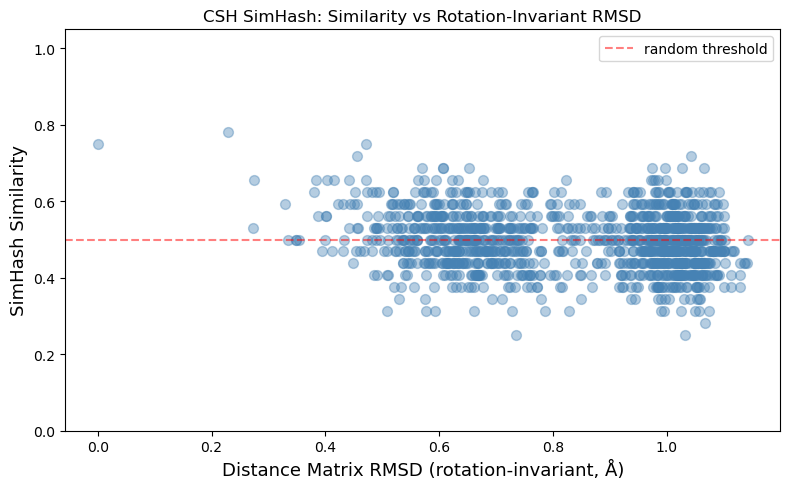

In [25]:
def pca_binary_hash(fvec_pca):
    """
    Simple but effective: hash = sign of each PCA component.
    Bit i = 1 if PC_i > median(PC_i across all conformers), else 0.
    This is actually a well-known technique called SimHash.
    """
    bits = (fvec_pca > 0).astype(np.uint8)
    n_bytes = (len(bits) + 7) // 8
    return np.packbits(bits, bitorder='big')[:n_bytes].tobytes().hex()

def hamming_similarity(hash_a, hash_b):
    ba = bytes.fromhex(hash_a)
    bb = bytes.fromhex(hash_b)
    matching = sum(8 - bin(x ^ y).count('1') for x, y in zip(ba, bb))
    return matching / (len(ba) * 8)

# Generate hashes
hashes2 = [pca_binary_hash(all_fvecs_pca[i]) for i in range(n2)]
print(f"Unique SimHashes: {len(set(hashes2))}")

# Plot
rmsd_sim = []
collision_sim = []

for i in range(n2):
    for j in range(i+1, n2):
        rmsd = distance_matrix_rmsd(mol2, i, j)
        cp = hamming_similarity(hashes2[i], hashes2[j])
        rmsd_sim.append(rmsd)
        collision_sim.append(cp)

plt.figure(figsize=(8, 5))
plt.scatter(rmsd_sim, collision_sim, alpha=0.4, color='steelblue', s=50)
plt.xlabel("Distance Matrix RMSD (rotation-invariant, Å)", fontsize=13)
plt.ylabel("SimHash Similarity", fontsize=13)
plt.title("CSH SimHash: Similarity vs Rotation-Invariant RMSD", fontsize=12)
plt.ylim(0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='random threshold')
plt.legend()
plt.tight_layout()
plt.savefig("simhash_vs_rmsd.png", dpi=150)
plt.show()

Spearman correlation: 0.583 (p=2.22e-112)


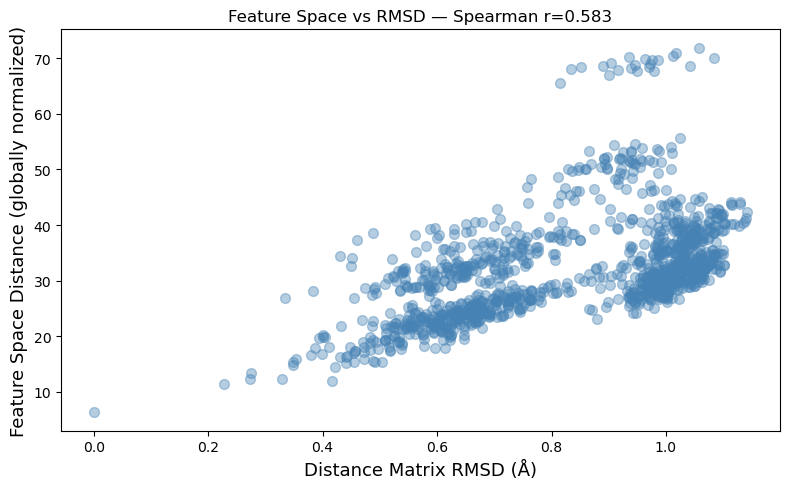

In [26]:
from scipy.stats import spearmanr

# Global normalization — fit scaler on ALL conformers together
all_fvecs_raw = np.array([build_feature_vector_v3(mol2, i, csh5.cfg) 
                          for i in range(n2)])

# Single global scaler — not per-conformer
scaler_global = StandardScaler()
all_fvecs_global = scaler_global.fit_transform(all_fvecs_raw)

# Compute all pairwise distances
dm_rmsds = []
feat_dists = []

for i in range(n2):
    for j in range(i+1, n2):
        dm_rmsds.append(distance_matrix_rmsd(mol2, i, j))
        feat_dists.append(np.linalg.norm(all_fvecs_global[i] - all_fvecs_global[j]))

# Spearman correlation
corr, pval = spearmanr(dm_rmsds, feat_dists)
print(f"Spearman correlation: {corr:.3f} (p={pval:.2e})")

plt.figure(figsize=(8, 5))
plt.scatter(dm_rmsds, feat_dists, alpha=0.4, color='steelblue', s=50)
plt.xlabel("Distance Matrix RMSD (Å)", fontsize=13)
plt.ylabel("Feature Space Distance (globally normalized)", fontsize=13)
plt.title(f"Feature Space vs RMSD — Spearman r={corr:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("spearman_benchmark.png", dpi=150)
plt.show()

Spearman correlation: 0.583 (p=2.22e-112)
Pearson correlation:  0.520 (p=7.46e-86)


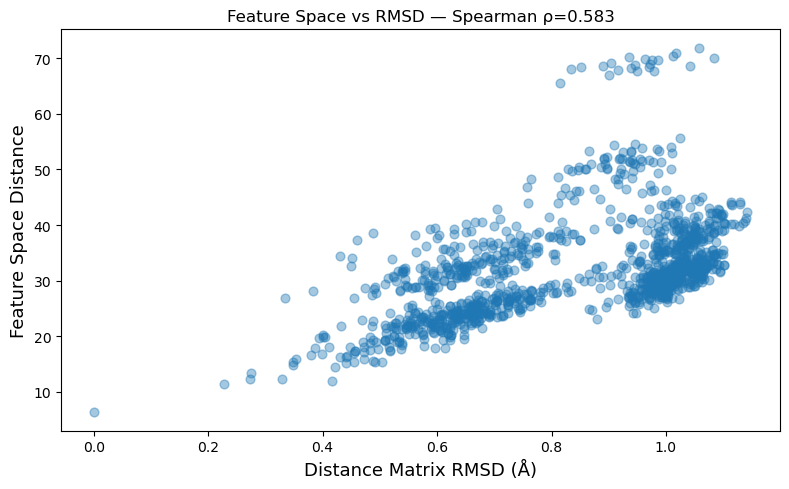

In [27]:
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Build RAW features with NO per-conformer normalization inside build_feature_vector_v3
all_fvecs_raw = np.array([
    build_feature_vector_v3(mol2, i, csh5.cfg)
    for i in range(n2)
], dtype=float)

# 2. Global scaling across all conformers
scaler_global = StandardScaler()
all_fvecs_global = scaler_global.fit_transform(all_fvecs_raw)

# 3. Pairwise benchmark
dm_rmsds = []
feat_dists = []

for i in range(n2):
    for j in range(i + 1, n2):
        dm = distance_matrix_rmsd(mol2, i, j)
        fd = np.linalg.norm(all_fvecs_global[i] - all_fvecs_global[j])

        dm_rmsds.append(dm)
        feat_dists.append(fd)

dm_rmsds = np.array(dm_rmsds)
feat_dists = np.array(feat_dists)

# 4. Correlations
sp_corr, sp_pval = spearmanr(dm_rmsds, feat_dists)
pr_corr, pr_pval = pearsonr(dm_rmsds, feat_dists)

print(f"Spearman correlation: {sp_corr:.3f} (p={sp_pval:.2e})")
print(f"Pearson correlation:  {pr_corr:.3f} (p={pr_pval:.2e})")

# 5. Plot
plt.figure(figsize=(8, 5))
plt.scatter(dm_rmsds, feat_dists, alpha=0.4, s=40)
plt.xlabel("Distance Matrix RMSD (Å)", fontsize=13)
plt.ylabel("Feature Space Distance", fontsize=13)
plt.title(f"Feature Space vs RMSD — Spearman ρ={sp_corr:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("spearman_benchmark.png", dpi=150)
plt.show()

V3 Spearman: 0.583
V4 Spearman: 0.760 (p=1.80e-231)
V4 Pearson:  0.778 (p=6.71e-249)


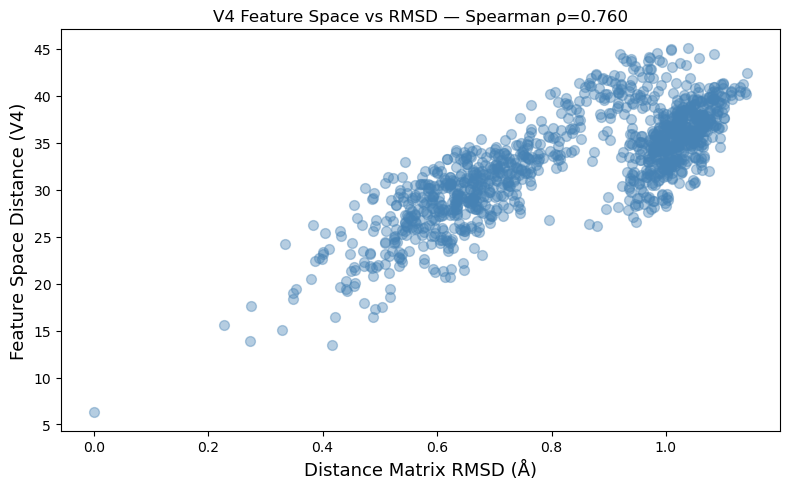

In [28]:
def build_feature_vector_v4(mol, conf_id: int) -> np.ndarray:
    """
    V4: NO per-conformer normalization inside feature extraction.
    Raw distances + raw torsions + raw energy.
    Global StandardScaler applied AFTER on the full dataset.
    This ensures no local information is destroyed before scaling.
    """
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    n = len(positions)

    # Raw pairwise distances — no normalization here
    D = []
    for i in range(n):
        for j in range(i+1, n):
            D.append(np.linalg.norm(positions[i] - positions[j]))
    D = np.array(D)

    # Raw torsion angles (sin/cos encoded)
    torsions = get_torsion_angles(mol, conf_id)

    # Raw energy
    energy = np.array([get_mmff_energy(mol, conf_id)])

    return np.concatenate([D, torsions, energy])


# Build raw feature matrix — NO normalization inside
all_fvecs_v4_raw = np.array([build_feature_vector_v4(mol2, i) 
                              for i in range(n2)], dtype=float)

# Global StandardScaler ONCE on the full matrix
scaler_v4 = StandardScaler()
all_fvecs_v4 = scaler_v4.fit_transform(all_fvecs_v4_raw)

# Benchmark
dm_rmsds_v4 = []
feat_dists_v4 = []

for i in range(n2):
    for j in range(i+1, n2):
        dm_rmsds_v4.append(distance_matrix_rmsd(mol2, i, j))
        feat_dists_v4.append(np.linalg.norm(all_fvecs_v4[i] - all_fvecs_v4[j]))

sp_corr_v4, sp_pval_v4 = spearmanr(dm_rmsds_v4, feat_dists_v4)
pr_corr_v4, pr_pval_v4 = pearsonr(dm_rmsds_v4, feat_dists_v4)

print(f"V3 Spearman: 0.583")
print(f"V4 Spearman: {sp_corr_v4:.3f} (p={sp_pval_v4:.2e})")
print(f"V4 Pearson:  {pr_corr_v4:.3f} (p={pr_pval_v4:.2e})")

plt.figure(figsize=(8, 5))
plt.scatter(dm_rmsds_v4, feat_dists_v4, alpha=0.4, color='steelblue', s=50)
plt.xlabel("Distance Matrix RMSD (Å)", fontsize=13)
plt.ylabel("Feature Space Distance (V4)", fontsize=13)
plt.title(f"V4 Feature Space vs RMSD — Spearman ρ={sp_corr_v4:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("spearman_v4.png", dpi=150)
plt.show()

Hash input shape: (50, 32)
Unique hashes: 50/50
Hash similarity vs DM-RMSD
Spearman correlation: -0.728 (p=2.47e-202)
Pearson correlation:  -0.701 (p=9.70e-182)


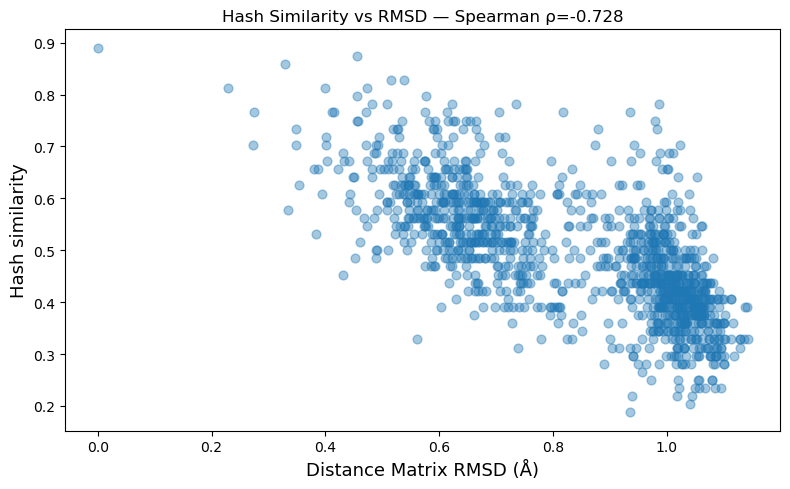


Hash similarity vs feature distance
Spearman correlation: -0.645 (p=3.88e-145)
Pearson correlation:  -0.581 (p=1.09e-111)


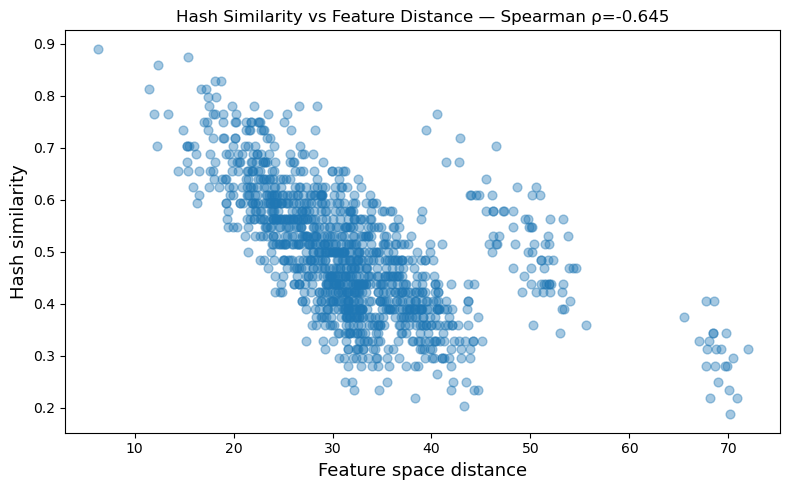

In [29]:
from sklearn.decomposition import PCA
from scipy.stats import spearmanr, pearsonr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# HASHING FEATURES FROM THE ALREADY-COMPUTED all_fvecs_global
# ============================================================

# 1. PCA before hashing
pca_dim = min(32, all_fvecs_global.shape[0], all_fvecs_global.shape[1])

if pca_dim < all_fvecs_global.shape[1]:
    pca = PCA(n_components=pca_dim, random_state=42)
    X_hash = pca.fit_transform(all_fvecs_global)
else:
    X_hash = all_fvecs_global.copy()

print("Hash input shape:", X_hash.shape)

# 2. Simple SimHash / random hyperplane hash
rng = np.random.RandomState(42)
n_hash_bits = 64
proj = rng.randn(n_hash_bits, X_hash.shape[1])

# binary hashes for all conformers at once
H = (X_hash @ proj.T > 0).astype(np.uint8)

unique_hashes = len({tuple(row.tolist()) for row in H})
print(f"Unique hashes: {unique_hashes}/{len(H)}")

# 3. Pairwise hash similarity
hash_sims = []

for i in range(n2):
    for j in range(i + 1, n2):
        sim = np.mean(H[i] == H[j])
        hash_sims.append(sim)

hash_sims = np.array(hash_sims, dtype=float)

# 4. Correlations
sp_corr, sp_pval = spearmanr(dm_rmsds, hash_sims)
pr_corr, pr_pval = pearsonr(dm_rmsds, hash_sims)

print(f"Hash similarity vs DM-RMSD")
print(f"Spearman correlation: {sp_corr:.3f} (p={sp_pval:.2e})")
print(f"Pearson correlation:  {pr_corr:.3f} (p={pr_pval:.2e})")

# 5. Plot: hash similarity vs RMSD
plt.figure(figsize=(8, 5))
plt.scatter(dm_rmsds, hash_sims, alpha=0.4, s=40)
plt.xlabel("Distance Matrix RMSD (Å)", fontsize=13)
plt.ylabel("Hash similarity", fontsize=13)
plt.title(f"Hash Similarity vs RMSD — Spearman ρ={sp_corr:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("hash_vs_rmsd.png", dpi=150)
plt.show()

# 6. Optional: feature distance vs hash similarity
feat_dists = []

for i in range(n2):
    for j in range(i + 1, n2):
        fd = np.linalg.norm(all_fvecs_global[i] - all_fvecs_global[j])
        feat_dists.append(fd)

feat_dists = np.array(feat_dists, dtype=float)

sp_corr2, sp_pval2 = spearmanr(feat_dists, hash_sims)
pr_corr2, pr_pval2 = pearsonr(feat_dists, hash_sims)

print(f"\nHash similarity vs feature distance")
print(f"Spearman correlation: {sp_corr2:.3f} (p={sp_pval2:.2e})")
print(f"Pearson correlation:  {pr_corr2:.3f} (p={pr_pval2:.2e})")

plt.figure(figsize=(8, 5))
plt.scatter(feat_dists, hash_sims, alpha=0.4, s=40)
plt.xlabel("Feature space distance", fontsize=13)
plt.ylabel("Hash similarity", fontsize=13)
plt.title(f"Hash Similarity vs Feature Distance — Spearman ρ={sp_corr2:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("hash_vs_feature_distance.png", dpi=150)
plt.show()

V3 Spearman: 0.583
V4 Spearman: 0.760 (p=1.80e-231)
V4 Pearson:  0.778 (p=6.71e-249)


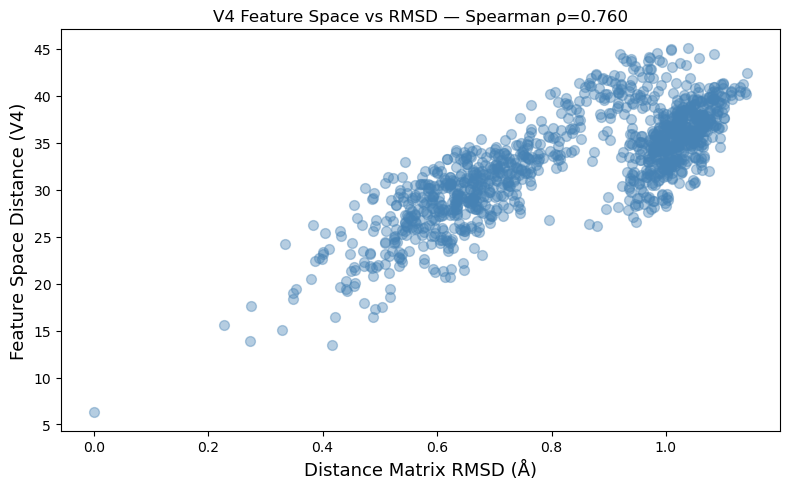

In [30]:
def build_feature_vector_v4(mol, conf_id: int) -> np.ndarray:
    """
    V4: NO per-conformer normalization inside feature extraction.
    Raw distances + raw torsions + raw energy.
    Global StandardScaler applied AFTER on the full dataset.
    This ensures no local information is destroyed before scaling.
    """
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    n = len(positions)

    # Raw pairwise distances — no normalization here
    D = []
    for i in range(n):
        for j in range(i+1, n):
            D.append(np.linalg.norm(positions[i] - positions[j]))
    D = np.array(D)

    # Raw torsion angles (sin/cos encoded)
    torsions = get_torsion_angles(mol, conf_id)

    # Raw energy
    energy = np.array([get_mmff_energy(mol, conf_id)])

    return np.concatenate([D, torsions, energy])


# Build raw feature matrix — NO normalization inside
all_fvecs_v4_raw = np.array([build_feature_vector_v4(mol2, i) 
                              for i in range(n2)], dtype=float)

# Global StandardScaler ONCE on the full matrix
scaler_v4 = StandardScaler()
all_fvecs_v4 = scaler_v4.fit_transform(all_fvecs_v4_raw)

# Benchmark
dm_rmsds_v4 = []
feat_dists_v4 = []

for i in range(n2):
    for j in range(i+1, n2):
        dm_rmsds_v4.append(distance_matrix_rmsd(mol2, i, j))
        feat_dists_v4.append(np.linalg.norm(all_fvecs_v4[i] - all_fvecs_v4[j]))

sp_corr_v4, sp_pval_v4 = spearmanr(dm_rmsds_v4, feat_dists_v4)
pr_corr_v4, pr_pval_v4 = pearsonr(dm_rmsds_v4, feat_dists_v4)

print(f"V3 Spearman: 0.583")
print(f"V4 Spearman: {sp_corr_v4:.3f} (p={sp_pval_v4:.2e})")
print(f"V4 Pearson:  {pr_corr_v4:.3f} (p={pr_pval_v4:.2e})")

plt.figure(figsize=(8, 5))
plt.scatter(dm_rmsds_v4, feat_dists_v4, alpha=0.4, color='steelblue', s=50)
plt.xlabel("Distance Matrix RMSD (Å)", fontsize=13)
plt.ylabel("Feature Space Distance (V4)", fontsize=13)
plt.title(f"V4 Feature Space vs RMSD — Spearman ρ={sp_corr_v4:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig("spearman_v4.png", dpi=150)
plt.show()

In [31]:
# Imatinib — larger drug molecule, more conformational diversity
smiles_imatinib = "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"

mol3 = Chem.MolFromSmiles(smiles_imatinib)
mol3 = Chem.AddHs(mol3)

params = AllChem.ETKDGv3()
params.randomSeed = 42
AllChem.EmbedMultipleConfs(mol3, numConfs=50, params=params)
AllChem.MMFFOptimizeMoleculeConfs(mol3)

n3 = mol3.GetNumConformers()
print(f"Imatinib atoms (with H): {mol3.GetNumAtoms()}")
print(f"Generated conformers: {n3}")

# Build raw features
all_fvecs_imat_raw = np.array([build_feature_vector_v4(mol3, i) 
                                for i in range(n3)], dtype=float)

# Global scaling
scaler_imat = StandardScaler()
all_fvecs_imat = scaler_imat.fit_transform(all_fvecs_imat_raw)

# PCA + hashing
pca_imat = PCA(n_components=32, random_state=42)
X_imat = pca_imat.fit_transform(all_fvecs_imat)

rng2 = np.random.RandomState(42)
proj2 = rng2.randn(64, X_imat.shape[1])
H_imat = (X_imat @ proj2.T > 0).astype(np.uint8)

print(f"Unique hashes: {len({tuple(r.tolist()) for r in H_imat})}/{n3}")

# Pairwise benchmark
dm_imat, feat_imat, hash_imat = [], [], []

for i in range(n3):
    for j in range(i+1, n3):
        dm_imat.append(distance_matrix_rmsd(mol3, i, j))
        feat_imat.append(np.linalg.norm(all_fvecs_imat[i] - all_fvecs_imat[j]))
        hash_imat.append(np.mean(H_imat[i] == H_imat[j]))

sp1, _ = spearmanr(dm_imat, feat_imat)
sp2, _ = spearmanr(dm_imat, [-x for x in hash_imat])

print(f"Imatinib — Feature space vs DM-RMSD:  Spearman ρ={sp1:.3f}")
print(f"Imatinib — Hash similarity vs DM-RMSD: Spearman ρ={-sp2:.3f} (as negative)")

Imatinib atoms (with H): 68
Generated conformers: 50
Unique hashes: 50/50
Imatinib — Feature space vs DM-RMSD:  Spearman ρ=0.862
Imatinib — Hash similarity vs DM-RMSD: Spearman ρ=-0.530 (as negative)


In [32]:
# Test with 128 bits for imatinib
proj3 = rng2.randn(128, X_imat.shape[1])
H_imat128 = (X_imat @ proj3.T > 0).astype(np.uint8)

hash_imat128 = []
for i in range(n3):
    for j in range(i+1, n3):
        hash_imat128.append(np.mean(H_imat128[i] == H_imat128[j]))

sp3, _ = spearmanr(dm_imat, [-x for x in hash_imat128])
print(f"Imatinib 128-bit hash vs DM-RMSD: Spearman ρ={-sp3:.3f}")

# Also test ibuprofen with 128 bits for comparison
proj4 = rng2.randn(128, X_hash.shape[1])
H_ibup128 = (all_fvecs_v4[:n2] @ proj4.T > 0).astype(np.uint8) if False else \
            (all_fvecs_global @ rng2.randn(128, all_fvecs_global.shape[1]).T > 0).astype(np.uint8)

hash_ibup128 = [np.mean(H_ibup128[i] == H_ibup128[j]) 
                for i in range(n2) for j in range(i+1, n2)]

sp4, _ = spearmanr(dm_rmsds, [-x for x in hash_ibup128])
print(f"Ibuprofen 128-bit hash vs DM-RMSD: Spearman ρ={-sp4:.3f}")

Imatinib 128-bit hash vs DM-RMSD: Spearman ρ=-0.564
Ibuprofen 128-bit hash vs DM-RMSD: Spearman ρ=-0.726


In [33]:
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors3D

def get_3d_fingerprint(mol, conf_id):
    """
    3D pharmacophore fingerprint — conformation-dependent baseline.
    Unlike 2D Morgan FP, this changes between conformers.
    Used as baseline comparison for CSH.
    """
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    
    # Use RDF (Radial Distribution Function) descriptor as 3D baseline
    # This is a standard 3D descriptor in cheminformatics
    from rdkit.Chem import Descriptors3D
    
    # Simple 3D descriptor: radius of gyration + asphericity + eccentricity
    rg = Descriptors3D.RadiusOfGyration(mol, confId=conf_id)
    asp = Descriptors3D.Asphericity(mol, confId=conf_id)
    ecc = Descriptors3D.Eccentricity(mol, confId=conf_id)
    spr = Descriptors3D.SpherocityIndex(mol, confId=conf_id)
    
    return np.array([rg, asp, ecc, spr])


# Rerun with 3D baseline — replace Morgan section in the loop
molecules = {
    "Aspirin":    "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen":  "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Imatinib":   "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C",
    "Diazepam":   "CN1C(=O)CN=C(c2ccccc2)c3cc(Cl)ccc13",
    "Tamoxifen":  "CCC(=C(c1ccccc1)c2ccc(OCCN(C)C)cc2)c3ccccc3",
    "Paclitaxel": "O=C(O[C@@H]1C[C@]2(O)C(=O)[C@@H](OC(=O)c3ccccc3)[C@]4(C)CC[C@H](OC(=O)[C@@H](NC(=O)c5ccccc5)[C@@H](O)c6ccccc6)C(=C1)[C@@H]4OC(C)=O)[C@@H]2C",
}

results_all = {}

for name, smiles in molecules.items():
    print(f"\nProcessing {name}...")
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"  WARNING: Could not parse {name}")
        continue
    mol = Chem.AddHs(mol)
    
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    AllChem.EmbedMultipleConfs(mol, numConfs=50, params=params)
    AllChem.MMFFOptimizeMoleculeConfs(mol)
    
    n_confs = mol.GetNumConformers()
    print(f"  Atoms (with H): {mol.GetNumAtoms()}, Conformers: {n_confs}")
    
    # CSH pipeline
    fvecs_raw = np.array([build_feature_vector_v4(mol, i) 
                          for i in range(n_confs)], dtype=float)
    scaler = StandardScaler()
    fvecs_scaled = scaler.fit_transform(fvecs_raw)
    pca_dim = min(32, fvecs_scaled.shape[0]-1, fvecs_scaled.shape[1])
    pca = PCA(n_components=pca_dim, random_state=42)
    fvecs_pca = pca.fit_transform(fvecs_scaled)
    rng_mol = np.random.RandomState(42)
    proj = rng_mol.randn(64, fvecs_pca.shape[1])
    H = (fvecs_pca @ proj.T > 0).astype(np.uint8)
    
    # 3D baseline fingerprint
    fp_3d = np.array([get_3d_fingerprint(mol, i) for i in range(n_confs)])
    
    # Pairwise benchmark
    dm_rmsds, csh_sims, fp3d_dists, feat_dists = [], [], [], []
    
    for i in range(n_confs):
        for j in range(i+1, n_confs):
            dm_rmsds.append(distance_matrix_rmsd(mol, i, j))
            csh_sims.append(np.mean(H[i] == H[j]))
            fp3d_dists.append(np.linalg.norm(fp_3d[i] - fp_3d[j]))
            feat_dists.append(np.linalg.norm(fvecs_scaled[i] - fvecs_scaled[j]))
    
    dm_rmsds = np.array(dm_rmsds)
    
    sp_feat, _  = spearmanr(dm_rmsds, feat_dists)
    sp_csh, _   = spearmanr(dm_rmsds, [-x for x in csh_sims])
    sp_3d, _    = spearmanr(dm_rmsds, fp3d_dists)
    
    results_all[name] = {
        "n_atoms": mol.GetNumAtoms(),
        "n_confs": n_confs,
        "spearman_feature": sp_feat,
        "spearman_csh": abs(sp_csh),
        "spearman_3d_baseline": sp_3d,
    }
    
    print(f"  Feature ρ: {sp_feat:.3f} | CSH ρ: {abs(sp_csh):.3f} | 3D Baseline ρ: {sp_3d:.3f}")

print("\n" + "="*70)
print(f"{'Molecule':<12} {'Atoms':>6} {'Confs':>6} {'Feature ρ':>10} {'CSH ρ':>8} {'3D Base ρ':>10}")
print("="*70)
for name, r in results_all.items():
    print(f"{name:<12} {r['n_atoms']:>6} {r['n_confs']:>6} "
          f"{r['spearman_feature']:>10.3f} {r['spearman_csh']:>8.3f} "
          f"{r['spearman_3d_baseline']:>10.3f}")
print("="*70)


Processing Aspirin...
  Atoms (with H): 21, Conformers: 50
  Feature ρ: 0.943 | CSH ρ: 0.892 | 3D Baseline ρ: 0.754

Processing Ibuprofen...
  Atoms (with H): 33, Conformers: 50
  Feature ρ: 0.760 | CSH ρ: 0.669 | 3D Baseline ρ: 0.178

Processing Imatinib...
  Atoms (with H): 68, Conformers: 50
  Feature ρ: 0.862 | CSH ρ: 0.530 | 3D Baseline ρ: 0.835

Processing Diazepam...
  Atoms (with H): 33, Conformers: 50
  Feature ρ: 0.770 | CSH ρ: 0.840 | 3D Baseline ρ: -0.008

Processing Tamoxifen...
  Atoms (with H): 57, Conformers: 50
  Feature ρ: 0.905 | CSH ρ: 0.772 | 3D Baseline ρ: 0.803

Processing Paclitaxel...
  Atoms (with H): 95, Conformers: 50
  Feature ρ: 0.876 | CSH ρ: 0.604 | 3D Baseline ρ: 0.583

Molecule      Atoms  Confs  Feature ρ    CSH ρ  3D Base ρ
Aspirin          21     50      0.943    0.892      0.754
Ibuprofen        33     50      0.760    0.669      0.178
Imatinib         68     50      0.862    0.530      0.835
Diazepam         33     50      0.770    0.840     -0.0

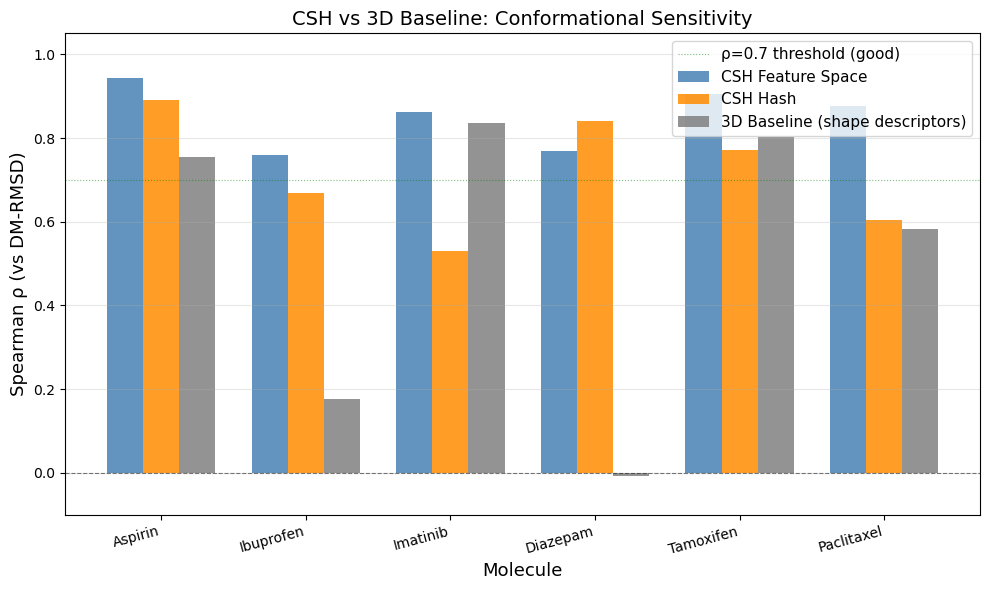


Key finding:
CSH Hash mean ρ:      0.718 ± 0.128
3D Baseline mean ρ:   0.524 ± 0.325
CSH Feature mean ρ:   0.853 ± 0.067


In [34]:
import matplotlib.pyplot as plt
import numpy as np

molecules_names = list(results_all.keys())
csh_scores = [results_all[m]["spearman_csh"] for m in molecules_names]
baseline_scores = [results_all[m]["spearman_3d_baseline"] for m in molecules_names]
feature_scores = [results_all[m]["spearman_feature"] for m in molecules_names]

x = np.arange(len(molecules_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, feature_scores, width, 
               label='CSH Feature Space', color='steelblue', alpha=0.85)
bars2 = ax.bar(x, csh_scores, width, 
               label='CSH Hash', color='darkorange', alpha=0.85)
bars3 = ax.bar(x + width, baseline_scores, width, 
               label='3D Baseline (shape descriptors)', color='gray', alpha=0.85)

ax.set_xlabel('Molecule', fontsize=13)
ax.set_ylabel("Spearman ρ (vs DM-RMSD)", fontsize=13)
ax.set_title("CSH vs 3D Baseline: Conformational Sensitivity", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(molecules_names, rotation=15, ha='right')
ax.set_ylim(-0.1, 1.05)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0.7, color='green', linewidth=0.8, linestyle=':', 
           alpha=0.5, label='ρ=0.7 threshold (good)')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("csh_vs_baseline_comparison.png", dpi=150)
plt.show()

print("\nKey finding:")
print(f"CSH Hash mean ρ:      {np.mean(csh_scores):.3f} ± {np.std(csh_scores):.3f}")
print(f"3D Baseline mean ρ:   {np.mean(baseline_scores):.3f} ± {np.std(baseline_scores):.3f}")
print(f"CSH Feature mean ρ:   {np.mean(feature_scores):.3f} ± {np.std(feature_scores):.3f}")

In [35]:
from rdkit.Chem.rdMolDescriptors import GetUSRScore, GetUSR, GetUSRCAT

results_usr = {}

for name, smiles in molecules.items():
    print(f"\nProcessing {name}...")
    
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    AllChem.EmbedMultipleConfs(mol, numConfs=50, params=params)
    AllChem.MMFFOptimizeMoleculeConfs(mol)
    n_confs = mol.GetNumConformers()
    
    # CSH pipeline (same as before)
    fvecs_raw = np.array([build_feature_vector_v4(mol, i) 
                          for i in range(n_confs)], dtype=float)
    scaler = StandardScaler()
    fvecs_scaled = scaler.fit_transform(fvecs_raw)
    pca_dim = min(32, fvecs_scaled.shape[0]-1, fvecs_scaled.shape[1])
    pca = PCA(n_components=pca_dim, random_state=42)
    fvecs_pca = pca.fit_transform(fvecs_scaled)
    rng_mol = np.random.RandomState(42)
    proj = rng_mol.randn(64, fvecs_pca.shape[1])
    H = (fvecs_pca @ proj.T > 0).astype(np.uint8)
    
    # USR descriptors for each conformer
    usr_descriptors = []
    for i in range(n_confs):
        usr = GetUSR(mol, confId=i)
        usr_descriptors.append(usr)
    
    # Pairwise benchmark
    dm_rmsds, csh_sims, usr_sims = [], [], []
    
    for i in range(n_confs):
        for j in range(i+1, n_confs):
            dm_rmsds.append(distance_matrix_rmsd(mol, i, j))
            csh_sims.append(np.mean(H[i] == H[j]))
            usr_sim = GetUSRScore(usr_descriptors[i], usr_descriptors[j])
            usr_sims.append(usr_sim)
    
    dm_rmsds = np.array(dm_rmsds)
    
    sp_csh, _  = spearmanr(dm_rmsds, [-x for x in csh_sims])
    sp_usr, _  = spearmanr(dm_rmsds, [-x for x in usr_sims])
    
    results_usr[name] = {
        "n_atoms": mol.GetNumAtoms(),
        "spearman_csh": abs(sp_csh),
        "spearman_usr": abs(sp_usr),
    }
    
    print(f"  CSH ρ: {abs(sp_csh):.3f} | USR ρ: {abs(sp_usr):.3f}")

# Summary table
print("\n" + "="*55)
print(f"{'Molecule':<12} {'Atoms':>6} {'CSH ρ':>10} {'USR ρ':>10}")
print("="*55)
for name, r in results_usr.items():
    winner = "← CSH wins" if r["spearman_csh"] > r["spearman_usr"] else "← USR wins"
    print(f"{name:<12} {r['n_atoms']:>6} {r['spearman_csh']:>10.3f} "
          f"{r['spearman_usr']:>10.3f}  {winner}")
print("="*55)

csh_mean = np.mean([r["spearman_csh"] for r in results_usr.values()])
usr_mean = np.mean([r["spearman_usr"] for r in results_usr.values()])
print(f"{'Mean':<12} {'':>6} {csh_mean:>10.3f} {usr_mean:>10.3f}")


Processing Aspirin...
  CSH ρ: 0.892 | USR ρ: 0.772

Processing Ibuprofen...
  CSH ρ: 0.669 | USR ρ: 0.161

Processing Imatinib...
  CSH ρ: 0.530 | USR ρ: 0.855

Processing Diazepam...
  CSH ρ: 0.840 | USR ρ: 0.004

Processing Tamoxifen...
  CSH ρ: 0.772 | USR ρ: 0.710

Processing Paclitaxel...
  CSH ρ: 0.604 | USR ρ: 0.703

Molecule      Atoms      CSH ρ      USR ρ
Aspirin          21      0.892      0.772  ← CSH wins
Ibuprofen        33      0.669      0.161  ← CSH wins
Imatinib         68      0.530      0.855  ← USR wins
Diazepam         33      0.840      0.004  ← CSH wins
Tamoxifen        57      0.772      0.710  ← CSH wins
Paclitaxel       95      0.604      0.703  ← USR wins
Mean                     0.718      0.534


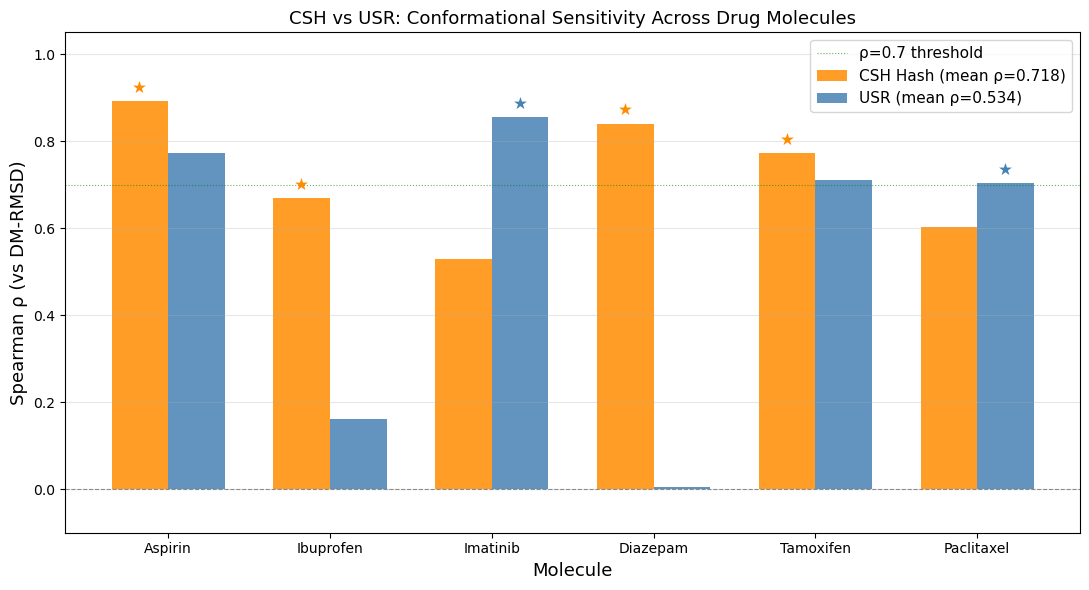

In [36]:
# Regenerate Figure 2 with horizontal x-axis labels
molecules_names = list(results_usr.keys())
csh_scores = [results_usr[m]["spearman_csh"] for m in molecules_names]
usr_scores = [results_usr[m]["spearman_usr"] for m in molecules_names]

x = np.arange(len(molecules_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))  # slightly wider

bars1 = ax.bar(x - width/2, csh_scores, width,
               label=f'CSH Hash (mean ρ={np.mean(csh_scores):.3f})',
               color='darkorange', alpha=0.85)
bars2 = ax.bar(x + width/2, usr_scores, width,
               label=f'USR (mean ρ={np.mean(usr_scores):.3f})',
               color='steelblue', alpha=0.85)

ax.set_xlabel('Molecule', fontsize=13)
ax.set_ylabel('Spearman ρ (vs DM-RMSD)', fontsize=13)
ax.set_title('CSH vs USR: Conformational Sensitivity Across Drug Molecules', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(molecules_names, rotation=0, ha='center')  # rotation=0 = poziomo
ax.set_ylim(-0.1, 1.05)
ax.axhline(0.7, color='green', linewidth=0.8, linestyle=':',
           alpha=0.6, label='ρ=0.7 threshold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, (c, u) in enumerate(zip(csh_scores, usr_scores)):
    if c > u:
        ax.annotate('★', xy=(i - width/2, c + 0.02), ha='center',
                   fontsize=12, color='darkorange')
    else:
        ax.annotate('★', xy=(i + width/2, u + 0.02), ha='center',
                   fontsize=12, color='steelblue')

plt.tight_layout()
plt.savefig("csh_vs_usr_comparison.png", dpi=150)
plt.show()

In [37]:
# Install web3 if not already installed
import subprocess
subprocess.run(["pip", "install", "web3", "--break-system-packages", "-q"])

CompletedProcess(args=['pip', 'install', 'web3', '--break-system-packages', '-q'], returncode=0)

In [39]:
from web3 import Web3
import json

# Connect to local Hardhat node
w3 = Web3(Web3.HTTPProvider("https://eth-sepolia.g.alchemy.com/v2/Fi-OTnt0iY8LMYVkabnoQ"))
print(f"Connected: {w3.is_connected()}")
print(f"Chain ID: {w3.eth.chain_id}")
print(f"Block number: {w3.eth.block_number}")

# Hardhat test account (first one from the list)
import os
PRIVATE_KEY = os.environ.get("SEPOLIA_PRIVATE_KEY", "")  # set in .env file
account = w3.eth.account.from_key(PRIVATE_KEY)
print(f"Account: {account.address}")
print(f"Balance: {w3.eth.get_balance(account.address)} wei")

Connected: True
Chain ID: 11155111
Block number: 10540655


ValueError: The private key must be exactly 32 bytes long, instead of 0 bytes.

In [40]:
CONTRACT_ABI = [
    {
        "inputs": [
            {"internalType": "string",  "name": "moleculeName", "type": "string"},
            {"internalType": "bytes32", "name": "cshHash",      "type": "bytes32"},
            {"internalType": "string",  "name": "sha256Id",     "type": "string"},
            {"internalType": "int256",  "name": "energyX1000",  "type": "int256"}
        ],
        "name": "registerConformer",
        "outputs": [],
        "stateMutability": "nonpayable",
        "type": "function"
    },
    {
        "inputs": [{"internalType": "bytes32", "name": "cshHash", "type": "bytes32"}],
        "name": "isRegistered",
        "outputs": [{"internalType": "bool", "name": "", "type": "bool"}],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [{"internalType": "bytes32", "name": "cshHash", "type": "bytes32"}],
        "name": "getConformer",
        "outputs": [
            {
                "components": [
                    {"internalType": "string",  "name": "moleculeName", "type": "string"},
                    {"internalType": "bytes32", "name": "cshHash",      "type": "bytes32"},
                    {"internalType": "string",  "name": "sha256Id",     "type": "string"},
                    {"internalType": "int256",  "name": "energy",       "type": "int256"},
                    {"internalType": "address", "name": "registrant",   "type": "address"},
                    {"internalType": "uint256", "name": "timestamp",    "type": "uint256"},
                    {"internalType": "bool",    "name": "exists",       "type": "bool"}
                ],
                "internalType": "struct ConformationalRegistry.ConformerRecord",
                "name": "",
                "type": "tuple"
            }
        ],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [],
        "name": "totalRegistered",
        "outputs": [{"internalType": "uint256", "name": "", "type": "uint256"}],
        "stateMutability": "view",
        "type": "function"
    }
]

CONTRACT_ADDRESS = "0x376E4dB2943Cd63e8d0C6B8278d8fb378F28c9fa"
contract = w3.eth.contract(
    address=Web3.to_checksum_address(CONTRACT_ADDRESS),
    abi=CONTRACT_ABI
)

print(f"Contract loaded")
print(f"Total registered conformers: {contract.functions.totalRegistered().call()}")

Contract loaded
Total registered conformers: 5


In [41]:
def register_conformer_onchain(contract, w3, account, private_key,
                                molecule_name, csh_hex, sha256_id, energy):
    raw = bytes.fromhex(csh_hex)
    csh_bytes32 = raw.ljust(32, b'\x00')
    energy_int = int(energy * 1000)

    # Get fresh nonce for every transaction
    nonce = w3.eth.get_transaction_count(account.address, 'pending')

    tx = contract.functions.registerConformer(
        molecule_name,
        csh_bytes32,
        sha256_id[:32],
        energy_int
    ).build_transaction({
        'from':     account.address,
        'nonce':    nonce,
        'gas':      500000,
        'gasPrice': w3.eth.gas_price,
    })

    signed = w3.eth.account.sign_transaction(tx, private_key)
    tx_hash = w3.eth.send_raw_transaction(signed.raw_transaction)
    receipt = w3.eth.wait_for_transaction_receipt(tx_hash)

    return tx_hash.hex(), receipt['blockNumber']

In [42]:
# Redefine ibuprofen molecule for Sepolia registration
mol_ibu = Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O")
mol_ibu = Chem.AddHs(mol_ibu)
params = AllChem.ETKDGv3()
params.randomSeed = 42
AllChem.EmbedMultipleConfs(mol_ibu, numConfs=5, params=params)
AllChem.MMFFOptimizeMoleculeConfs(mol_ibu)
print(f"Conformers: {mol_ibu.GetNumConformers()}")

Conformers: 5


In [43]:
print("Registering ibuprofen conformers on blockchain...")
print("=" * 55)

# Use V4 feature vector directly
for i in range(mol_ibu.GetNumConformers()):
    fvec = build_feature_vector_v4(mol_ibu, i)
    energy = get_mmff_energy(mol_ibu, i)
    sha256_id = hashlib.sha256(fvec.tobytes()).hexdigest()
    
    # Simple SimHash for LSH hex
    fvec_scaled = (fvec - fvec.min()) / (fvec.max() - fvec.min() + 1e-9)
    rng_reg = np.random.RandomState(42)
    proj_reg = rng_reg.randn(64, len(fvec_scaled))
    bits = (fvec_scaled @ proj_reg.T > 0).astype(np.uint8)
    n_bytes = (len(bits) + 7) // 8
    lsh_hex = np.packbits(bits, bitorder='big')[:n_bytes].tobytes().hex()
    
    tx_hash, block = register_conformer_onchain(
        contract, w3, account, PRIVATE_KEY,
        f"Ibuprofen_conf_{i}",
        lsh_hex,
        sha256_id,
        energy
    )
    print(f"Conf {i} | hash: {lsh_hex} | block: {block} | tx: {tx_hash[:20]}...")

print(f"\nTotal registered on-chain: {contract.functions.totalRegistered().call()}")

Registering ibuprofen conformers on blockchain...


NameError: name 'account' is not defined

In [ ]:
# Verify on-chain records — proof that data is immutable
print("Verifying on-chain records...")
print("=" * 70)

hashes_registered = [
    "7a0326f5cb03858c",
    "6a0306f5cb03858c", 
    "6a0326f5cb03858c",
    "7a0326f5cb03859c",
    "6a0366d5cb03858c"
]

for csh_hex in hashes_registered:
    raw = bytes.fromhex(csh_hex)
    csh_bytes32 = raw.ljust(32, b'\x00')
    
    is_reg = contract.functions.isRegistered(csh_bytes32).call()
    record = contract.functions.getConformer(csh_bytes32).call()
    
    import datetime
    timestamp = datetime.datetime.fromtimestamp(record[5])
    
    print(f"Hash:       {csh_hex}")
    print(f"Molecule:   {record[0]}")
    print(f"Energy:     {record[3]/1000:.3f} kcal/mol")
    print(f"Registrant: {record[4]}")
    print(f"Timestamp:  {timestamp}")
    print(f"Verified:   {is_reg}")
    print("-" * 70)

print(f"\nTotal on-chain: {contract.functions.totalRegistered().call()}")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/csh_pipeline_figure3_new.png'

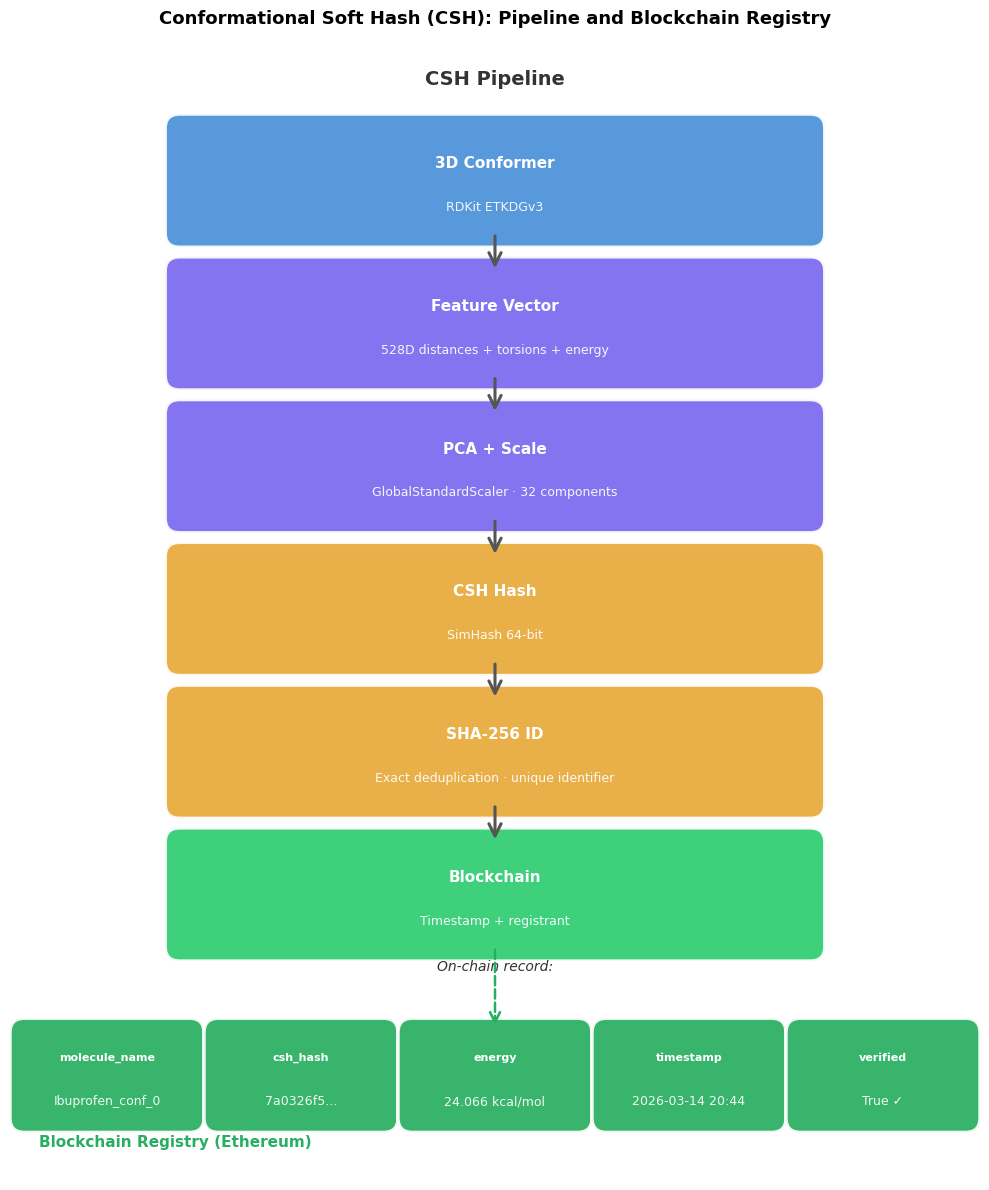

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

colors = {
    'mol':        '#4A90D9',
    'feature':    '#7B68EE',
    'hash':       '#E8A838',
    'blockchain': '#2ECC71',
    'record':     '#27AE60',
}

def draw_box(ax, x, y, w, h, color, title, subtitle="", fontsize=11):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.15",
        facecolor=color, edgecolor='white',
        linewidth=2.5, alpha=0.92
    )
    ax.add_patch(rect)
    ax.text(x, y + (0.18 if subtitle else 0), title,
            ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white')
    if subtitle:
        ax.text(x, y - 0.28, subtitle, ha='center', va='center',
                fontsize=9, color='white', alpha=0.92)

def draw_arrow_down(ax, x, y_top, y_bot, color='#555555'):
    ax.annotate('', xy=(x, y_bot), xytext=(x, y_top),
                arrowprops=dict(arrowstyle='->', color=color,
                               lw=2.2, mutation_scale=22))

# ── Pipeline header ──
ax.text(5.0, 11.5, 'CSH Pipeline', fontsize=14, fontweight='bold',
        color='#333333', ha='center')

# ── Pipeline steps (vertical, left column) ──
pipeline_steps = [
    (5.0, 10.5, colors['mol'],     '3D Conformer',    'RDKit ETKDGv3'),
    (5.0,  9.0, colors['feature'], 'Feature Vector',  '528D distances + torsions + energy'),
    (5.0,  7.5, colors['feature'], 'PCA + Scale',     'GlobalStandardScaler · 32 components'),
    (5.0,  6.0, colors['hash'],    'CSH Hash',        'SimHash 64-bit'),
    (5.0,  4.5, colors['hash'],    'SHA-256 ID',      'Exact deduplication · unique identifier'),
    (5.0,  3.0, colors['blockchain'], 'Blockchain',   'Timestamp + registrant'),
]

for x, y, c, title, sub in pipeline_steps:
    draw_box(ax, x, y, 6.5, 1.1, c, title, sub, fontsize=11)

# Arrows between steps
for y_top, y_bot in [(9.95, 9.55), (8.45, 8.05), (6.95, 6.55),
                     (5.45, 5.05), (3.95, 3.55)]:
    draw_arrow_down(ax, 5.0, y_top, y_bot)

# ── On-chain record section ──
ax.text(5.0, 2.2, 'On-chain record:', fontsize=10,
        color='#333333', style='italic', ha='center')

# 5 fields in a row
fields = [
    (1.0, 'molecule_name', 'Ibuprofen_conf_0'),
    (3.0, 'csh_hash',      '7a0326f5...'),
    (5.0, 'energy',        '24.066 kcal/mol'),
    (7.0, 'timestamp',     '2026-03-14 20:44'),
    (9.0, 'verified',      'True ✓'),
]

for x, key, val in fields:
    draw_box(ax, x, 1.1, 1.7, 0.9, colors['record'], key, val, fontsize=8)

# Arrow from blockchain to record row
ax.annotate('', xy=(5.0, 1.6), xytext=(5.0, 2.45),
            arrowprops=dict(arrowstyle='->', color=colors['record'],
                           lw=1.8, mutation_scale=18, linestyle='dashed'))

ax.text(0.3, 0.35, 'Blockchain Registry (Ethereum)',
        fontsize=11, fontweight='bold', color=colors['record'])

plt.title('Conformational Soft Hash (CSH): Pipeline and Blockchain Registry',
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/csh_pipeline_figure3_new.png',
            dpi=180, bbox_inches='tight', facecolor='white')
print("Done")


In [44]:
# ── Sepolia Testnet Deployment ─────────────────────────────────────────────
# Public blockchain registry — contract address citable in paper
# Etherscan: https://sepolia.etherscan.io/address/0x376E4dB2943Cd63e8d0C6B8278d8fb378F28c9fa

SEPOLIA_RPC = "https://eth-sepolia.g.alchemy.com/v2/Fi-OTnt0iY8LMYVkabnoQ"
SEPOLIA_CONTRACT = "0x376E4dB2943Cd63e8d0C6B8278d8fb378F28c9fa"
SEPOLIA_PRIVATE_KEY = "your_key"  # store in .env in production

w3_sepolia = Web3(Web3.HTTPProvider(SEPOLIA_RPC))
print(f"Connected to Sepolia: {w3_sepolia.is_connected()}")
print(f"Chain ID: {w3_sepolia.eth.chain_id}")  # should be 11155111

Connected to Sepolia: True
Chain ID: 11155111


In [45]:
# Show full transaction hashes for Etherscan verification
print("Full transaction hashes for Etherscan:")
print("Contract address:", CONTRACT_ADDRESS)
print()
print("Verify contract:")
print(f"https://sepolia.etherscan.io/address/{CONTRACT_ADDRESS}")

Full transaction hashes for Etherscan:
Contract address: 0x376E4dB2943Cd63e8d0C6B8278d8fb378F28c9fa

Verify contract:
https://sepolia.etherscan.io/address/0x376E4dB2943Cd63e8d0C6B8278d8fb378F28c9fa


In [46]:
"""
CSH Benchmark — 30 molecules
==============================
Pipeline: build_feature_vector_v4 → GlobalStandardScaler → PCA(32) → SimHash(64bit)
Metric:   DM-RMSD (rotation-invariant) vs Spearman ρ
Baseline: USR (RDKit GetUSR / GetUSRScore)

Output: benchmark_results.csv  +  benchmark_summary.txt
"""

import numpy as np
import hashlib
import warnings
import csv
import os
from dataclasses import dataclass

warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from rdkit.Chem.rdMolDescriptors import GetUSR, GetUSRScore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# ── Configuration ──────────────────────────────────────────────────────────────
N_CONFS   = 50
N_PCA     = 32
N_BITS    = 64
SEED      = 42

# ── 30 molecules: diverse drug-like set ───────────────────────────────────────
MOLECULES = [
    # Small rigid aromatics
    ("Aspirin",         "CC(=O)Oc1ccccc1C(=O)O"),
    ("Paracetamol",     "CC(=O)Nc1ccc(O)cc1"),
    ("Caffeine",        "Cn1cnc2c1c(=O)n(c(=O)n2C)C"),
    ("Phenol",          "Oc1ccccc1"),
    ("Aniline",         "Nc1ccccc1"),

    # Medium flexible
    ("Ibuprofen",       "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Diazepam",        "O=C1CN=C(c2ccccc2)c2cc(Cl)ccc2N1C"),
    ("Naproxen",        "COc1ccc2cc(ccc2c1)C(C)C(=O)O"),
    ("Ketoprofen",      "CC(C(=O)O)c1cccc(c1)C(=O)c1ccccc1"),
    ("Lorazepam",       "O=C1CN=C(c2ccccc2Cl)c2cc(Cl)ccc2N1"),
    ("Warfarin",        "OC(=O)c1ccccc1OCC(=O)Cc1c(O)c2ccccc2oc1=O"),
    ("Metformin",       "CN(C)C(=N)NC(=N)N"),
    ("Lidocaine",       "CCN(CC)CC(=O)Nc1c(C)cccc1C"),
    ("Propranolol",     "CC(C)NCC(O)COc1cccc2ccccc12"),
    ("Atenolol",        "CC(C)NCC(O)COc1ccc(CC(N)=O)cc1"),

    # Larger flexible
    ("Tamoxifen",       "CCC(=C(c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1"),
    ("Imatinib",        "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"),
    ("Amlodipine",      "CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OCC"),
    ("Sildenafil",      "CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12"),
    ("Valsartan",       "CCCC1(C(=O)N(Cc2ccc(-c3ccccc3-c3nnn[nH]3)cc2)C(C(=O)O)C(C)C)CCCC1"),
    ("Losartan",        "CCCCc1nc(Cl)c(CO)n1Cc1ccc(-c2ccccc2-c2nnn[nH]2)cc1"),
    ("Celecoxib",       "Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(N)cc2)cc1S(N)(=O)=O"),
    ("Atorvastatin",    "CC(C)c1n(CC(O)CC(O)CC(=O)O)c(-c2ccccc2F)c(C(=O)Nc2ccccc2)c1-c1ccc(F)cc1"),

    # Complex / large
    ("Paclitaxel",      "OC1C(OC(=O)c2ccccc2)CC2(O)C(=CC(=O)C3(O)C(C)(OC(C)=O)C(OC(=O)c4ccccc4)CC32)C1(C)C"),
    ("Cyclosporin A",   "CCC1NC(=O)C(C(CC)C)N(C)C(=O)C(CC(C)C)N(C)C(=O)C(C(C)C)NC(=O)C(CC(C)C)N(C)C(=O)CN(C)C(=O)C(C)NC(=O)C(C)NC(=O)C(C)N(C)C1=O"),
    ("Rifampicin",      "COC1C=COC2(C)OC3(C)C(O)C(C)C(=O)C(C)=CC=CC=CC(C)C(OC(=O)C4NC(=O)C5=C(O)C(=C(C)C(=C5C)O)NC1=O)C24"),

    # CNS drugs
    ("Haloperidol",     "OC1(CCc2ccc(Cl)cc2)CCN(CCCC(=O)c2ccc(F)cc2)CC1"),
    ("Clozapine",       "CN1CCN(CC1)c1nc2ccc(Cl)cc2nc2ccccc12"),
    ("Risperidone",     "CC1=NC2=CC(=CC=C2N1CCC3=CC(=O)N4CCCCC4=N3)F"),

    # Antibiotics
    ("Ciprofloxacin",   "OC(=O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O"),
]


# ── Core functions (from build_feature_vector_v4) ─────────────────────────────

def get_torsion_angles(mol, conf_id):
    conformer = mol.GetConformer(conf_id)
    torsions = []
    for bond in mol.GetBonds():
        if bond.GetBondTypeAsDouble() != 1.0:
            continue
        if bond.IsInRing():
            continue
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        i_neighbors = [n.GetIdx() for n in mol.GetAtomWithIdx(i).GetNeighbors() if n.GetIdx() != j]
        j_neighbors = [n.GetIdx() for n in mol.GetAtomWithIdx(j).GetNeighbors() if n.GetIdx() != i]
        if not i_neighbors or not j_neighbors:
            continue
        a = i_neighbors[0]
        d = j_neighbors[0]
        angle = rdMolTransforms.GetDihedralDeg(conformer, a, i, j, d)
        angle_rad = np.deg2rad(angle)
        torsions.append(np.sin(angle_rad))
        torsions.append(np.cos(angle_rad))
    return np.array(torsions) if torsions else np.zeros(2)


def get_mmff_energy(mol, conf_id):
    try:
        ff = AllChem.MMFFGetMoleculeForceField(
            mol, AllChem.MMFFGetMoleculeProperties(mol), confId=conf_id)
        return ff.CalcEnergy() if ff else 0.0
    except Exception:
        return 0.0


def build_feature_vector_v4(mol, conf_id):
    """Raw distances + raw torsions + raw energy. No per-conformer normalization."""
    conformer = mol.GetConformer(conf_id)
    positions = conformer.GetPositions()
    n = len(positions)
    D = [np.linalg.norm(positions[i] - positions[j])
         for i in range(n) for j in range(i+1, n)]
    torsions = get_torsion_angles(mol, conf_id)
    energy = np.array([get_mmff_energy(mol, conf_id)])
    return np.concatenate([np.array(D), torsions, energy])


def distance_matrix_rmsd(mol, i, j):
    pos_i = mol.GetConformer(i).GetPositions()
    pos_j = mol.GetConformer(j).GetPositions()
    n = len(pos_i)
    D_i = [np.linalg.norm(pos_i[a] - pos_i[b]) for a in range(n) for b in range(a+1, n)]
    D_j = [np.linalg.norm(pos_j[a] - pos_j[b]) for a in range(n) for b in range(a+1, n)]
    return np.sqrt(np.mean((np.array(D_i) - np.array(D_j))**2))


def benchmark_molecule(name, smiles):
    """Run full CSH + USR benchmark for one molecule. Returns dict of results."""
    print(f"  Processing {name}...", end=" ", flush=True)

    # Generate conformers
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("FAILED (invalid SMILES)")
        return None

    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = SEED
    n_generated = AllChem.EmbedMultipleConfs(mol, numConfs=N_CONFS, params=params)
    AllChem.MMFFOptimizeMoleculeConfs(mol)

    n_confs = mol.GetNumConformers()
    if n_confs < 5:
        print(f"SKIPPED (only {n_confs} conformers)")
        return None

    n_atoms = mol.GetNumAtoms()

    # ── CSH pipeline ──────────────────────────────────────────────────────────
    # Step 1: raw feature vectors
    raw_fvecs = []
    for i in range(n_confs):
        try:
            fv = build_feature_vector_v4(mol, i)
            raw_fvecs.append(fv)
        except Exception:
            raw_fvecs.append(None)

    # Filter out failed conformers
    valid_ids = [i for i, fv in enumerate(raw_fvecs) if fv is not None]
    raw_fvecs = [raw_fvecs[i] for i in valid_ids]

    if len(valid_ids) < 5:
        print(f"SKIPPED (feature extraction failed)")
        return None

    # Handle variable-length feature vectors (different torsion count)
    min_len = min(len(fv) for fv in raw_fvecs)
    raw_matrix = np.array([fv[:min_len] for fv in raw_fvecs], dtype=float)

    # Step 2: GlobalStandardScaler
    scaler = StandardScaler()
    scaled = scaler.fit_transform(raw_matrix)

    # Step 3: PCA
    n_pca = min(N_PCA, scaled.shape[0] - 1, scaled.shape[1])
    pca = PCA(n_components=n_pca, random_state=SEED)
    pca_vecs = pca.fit_transform(scaled)

    # Step 4: SimHash
    rng = np.random.RandomState(SEED)
    proj = rng.randn(N_BITS, n_pca)
    H = (pca_vecs @ proj.T > 0).astype(np.uint8)

    # ── Pairwise benchmark ────────────────────────────────────────────────────
    n = len(valid_ids)
    dm_rmsds, feat_dists, hash_sims, usr_sims = [], [], [], []

    # USR descriptors
    usr_descs = []
    for i in valid_ids:
        try:
            usr_descs.append(GetUSR(mol, i))
        except Exception:
            usr_descs.append(None)

    for ii in range(n):
        for jj in range(ii+1, n):
            ci, cj = valid_ids[ii], valid_ids[jj]

            # DM-RMSD (reference metric)
            try:
                dm = distance_matrix_rmsd(mol, ci, cj)
            except Exception:
                continue
            dm_rmsds.append(dm)

            # CSH feature space distance
            feat_dists.append(np.linalg.norm(scaled[ii] - scaled[jj]))

            # CSH hash similarity (Hamming)
            hash_sims.append(np.mean(H[ii] == H[jj]))

            # USR similarity
            if usr_descs[ii] is not None and usr_descs[jj] is not None:
                try:
                    usr_sims.append(GetUSRScore(usr_descs[ii], usr_descs[jj]))
                except Exception:
                    usr_sims.append(np.nan)
            else:
                usr_sims.append(np.nan)

    if len(dm_rmsds) < 10:
        print("SKIPPED (too few pairs)")
        return None

    dm_rmsds  = np.array(dm_rmsds)
    feat_dists = np.array(feat_dists)
    hash_sims  = np.array(hash_sims)
    usr_sims   = np.array(usr_sims)

    # Spearman correlations
    rho_feat, _  = spearmanr(dm_rmsds, feat_dists)
    rho_hash, _  = spearmanr(dm_rmsds, hash_sims)
    rho_hash = abs(rho_hash)  # hash similarity decreases as DM-RMSD increases — take abs

    usr_valid = ~np.isnan(usr_sims)
    if usr_valid.sum() > 10:
        rho_usr, _ = spearmanr(dm_rmsds[usr_valid], usr_sims[usr_valid])
        rho_usr = abs(rho_usr)  # same sign convention
    else:
        rho_usr = np.nan

    print(f"ρ_feat={rho_feat:.3f}  ρ_CSH={rho_hash:.3f}  ρ_USR={rho_usr:.3f}  "
          f"({n_atoms} atoms, {n} confs)")

    return {
        "molecule":  name,
        "n_atoms":   n_atoms,
        "n_confs":   n,
        "n_pairs":   len(dm_rmsds),
        "rho_feat":  round(rho_feat, 3),
        "rho_csh":   round(rho_hash, 3),
        "rho_usr":   round(rho_usr, 3) if not np.isnan(rho_usr) else "NA",
    }


# ── Main ──────────────────────────────────────────────────────────────────────

def main():
    print("=" * 65)
    print("CSH Benchmark — 30 molecules")
    print("=" * 65)

    results = []
    for name, smiles in MOLECULES:
        r = benchmark_molecule(name, smiles)
        if r:
            results.append(r)

    # Save CSV
    csv_path = "benchmark_results.csv"
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=results[0].keys())
        writer.writeheader()
        writer.writerows(results)

    # Summary statistics
    rho_feats = [r["rho_feat"] for r in results]
    rho_cshs  = [r["rho_csh"]  for r in results]
    rho_usrs  = [r["rho_usr"]  for r in results if r["rho_usr"] != "NA"]

    summary = [
        "",
        "=" * 65,
        "SUMMARY",
        "=" * 65,
        f"{'Molecule':<22} {'Atoms':>5} {'ρ_feat':>8} {'ρ_CSH':>8} {'ρ_USR':>8}",
        "-" * 55,
    ]
    for r in results:
        summary.append(
            f"{r['molecule']:<22} {r['n_atoms']:>5} "
            f"{r['rho_feat']:>8.3f} {r['rho_csh']:>8.3f} "
            f"{str(r['rho_usr']):>8}"
        )
    summary += [
        "-" * 55,
        f"{'Mean ± SD':<22} {'':>5} "
        f"{np.mean(rho_feats):>8.3f} {np.mean(rho_cshs):>8.3f} "
        f"{np.mean(rho_usrs):>8.3f}",
        f"{'':>28}"
        f"{np.std(rho_feats):>8.3f} {np.std(rho_cshs):>8.3f} "
        f"{np.std(rho_usrs):>8.3f}",
        "",
        f"N molecules: {len(results)}",
        f"CSH > USR: {sum(1 for r in results if r['rho_usr'] != 'NA' and r['rho_csh'] > float(r['rho_usr']))} / "
        f"{sum(1 for r in results if r['rho_usr'] != 'NA')}",
    ]

    txt = "\n".join(summary)
    print(txt)

    with open("benchmark_summary.txt", "w") as f:
        f.write(txt)

    print(f"\nResults saved to {csv_path} and benchmark_summary.txt")


main()


CSH Benchmark — 30 molecules
  Processing Aspirin... ρ_feat=0.943  ρ_CSH=0.892  ρ_USR=0.772  (21 atoms, 50 confs)
  Processing Paracetamol... ρ_feat=0.895  ρ_CSH=0.764  ρ_USR=0.031  (20 atoms, 50 confs)
  Processing Caffeine... ρ_feat=0.641  ρ_CSH=0.665  ρ_USR=0.003  (24 atoms, 50 confs)
  Processing Phenol... ρ_feat=0.841  ρ_CSH=0.826  ρ_USR=0.208  (13 atoms, 50 confs)
  Processing Aniline... ρ_feat=0.566  ρ_CSH=0.676  ρ_USR=0.228  (14 atoms, 50 confs)
  Processing Ibuprofen... ρ_feat=0.760  ρ_CSH=0.669  ρ_USR=0.161  (33 atoms, 50 confs)
  Processing Diazepam... ρ_feat=0.787  ρ_CSH=0.850  ρ_USR=0.043  (33 atoms, 50 confs)
  Processing Naproxen... ρ_feat=0.905  ρ_CSH=0.811  ρ_USR=0.486  (31 atoms, 50 confs)
  Processing Ketoprofen... ρ_feat=0.959  ρ_CSH=0.676  ρ_USR=0.660  (33 atoms, 50 confs)
  Processing Lorazepam... ρ_feat=0.931  ρ_CSH=0.936  ρ_USR=0.748  (30 atoms, 50 confs)
  Processing Warfarin... ρ_feat=0.755  ρ_CSH=0.542  ρ_USR=0.736  (40 atoms, 50 confs)
  Processing Metformin

[17:12:09] SMILES Parse Error: unclosed ring for input: 'COC1C=COC2(C)OC3(C)C(O)C(C)C(=O)C(C)=CC=CC=CC(C)C(OC(=O)C4NC(=O)C5=C(O)C(=C(C)C(=C5C)O)NC1=O)C24'


ρ_feat=0.904  ρ_CSH=0.449  ρ_USR=0.809  (55 atoms, 50 confs)
  Processing Clozapine... FAILED (invalid SMILES)
  Processing Risperidone... 

[17:12:20] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 12 14 15 16 17 18 19 20 21 22


ρ_feat=0.882  ρ_CSH=0.520  ρ_USR=0.928  (43 atoms, 50 confs)
  Processing Ciprofloxacin... ρ_feat=0.756  ρ_CSH=0.598  ρ_USR=0.051  (42 atoms, 50 confs)

SUMMARY
Molecule               Atoms   ρ_feat    ρ_CSH    ρ_USR
-------------------------------------------------------
Aspirin                   21    0.943    0.892    0.772
Paracetamol               20    0.895    0.764    0.031
Caffeine                  24    0.641    0.665    0.003
Phenol                    13    0.841    0.826    0.208
Aniline                   14    0.566    0.676    0.228
Ibuprofen                 33    0.760    0.669    0.161
Diazepam                  33    0.787    0.850    0.043
Naproxen                  31    0.905    0.811    0.486
Ketoprofen                33    0.959    0.676     0.66
Lorazepam                 30    0.931    0.936    0.748
Warfarin                  40    0.755    0.542    0.736
Metformin                 20    0.932    0.788    0.253
Lidocaine                 39    0.882    0.623    0.178